In [1]:
import pandas as pd
from pathlib import Path

# Load experiment 1 datasets
exp_dir = Path('../data/gold/experiment_1')
processes = [p for p in exp_dir.iterdir() if p.is_dir()]

results = []
for p in processes:

    print(p)
    dataset_dir = p / 'datasets'
    if not dataset_dir.exists():
        continue
    
    df_exp_path = dataset_dir / 'df_expanded.parquet'
    if not df_exp_path.exists():
        continue
        
    df = pd.read_parquet(df_exp_path)
    
    # Energy variables (contain 'energy' but NOT 'ef')
    energy_vars = [col for col in df.columns if 'to_model' in col.lower()]

    print(energy_vars)

    num_cols_energy = len(energy_vars) - 1

    
    
    # Number of cases
    case_col = 'case_id' if 'case_id' in df.columns else df.columns[0]
    num_cases = df[case_col].nunique() if case_col in df.columns else None
    
    # Number of activities
    activity_col = 'activity_log'
    num_activities = df[activity_col].nunique() if activity_col in df.columns else None

    # Max and min date, complete duration
    time_cols = [col for col in df.columns if 'time' in col.lower() or 'date' in col.lower()]
    time_col = time_cols[0] if time_cols else None
    if 'timestamp' in df.columns:
        time_col = 'timestamp'
    elif 'time:timestamp' in df.columns:
        time_col = 'time:timestamp'
        
    if time_col:
        # Try converting to datetime if not already
        df[time_col] = pd.to_datetime(df[time_col], errors='coerce')
        min_date = df[time_col].min()
        max_date = df[time_col].max()
        complete_date = max_date - min_date
        # Convert timedelta to total hours (rounded to 2 decimal places for readability)
        hours = round(complete_date.total_seconds() / 3600, 2) if pd.notnull(complete_date) else None
    else:
        min_date, max_date, hours = None, None, None
        
    # Number of rows in expanded
    num_rows = len(df)
    
    results.append({
        'dataset': p.name,
        'number of cases': num_cases,
        'number of activities': num_activities,
        'number of time series': num_cols_energy,
        'hours': int(round(hours)) if hours is not None else None,
        #'observations': num_rows
    })

# Sort and display the DataFrame
df_info = pd.DataFrame(results).sort_values(by='dataset')
display(df_info)

# Output a single LaTeX table for all datasets
print("\\begin{table}[h]")
print("\\centering")
print("\\caption{Dataset Information Overview}")
print(df_info.to_latex(index=False).replace('_', '\\_'))
print("\\end{table}")


../data/gold/experiment_1/process_4
['(10)_abluft_temp_c_energy_to_model', 'f10_speise_den_kg/m3_energy_to_model', '(12)_mpt_fb(mpt?)_kg/h_energy_to_model', 'f11_speise_mas_kg/h_energy_to_model', 'f11_speise_vol_l/h_energy_to_model', '(6)_nach_recu_reg_temp_c_energy_to_model', 'dampf_nassmischbereich_energy_to_model', '(3)_zuluft_nach_entfeuchter_kon_g/kg_energy_to_model', 'f10_speise_vol_l/h_energy_to_model', '(9)_abluft_kon_g/kg_energy_to_model', '(16)_konditionierung_mas_kg/h_energy_to_model', '(14)_filter_mas_kg/h_energy_to_model', 'f10_speise_mas_kg/h_energy_to_model', '(5)_vor_vent_hauptzuluft_temp_c_energy_to_model', '(7)_zuluft_turm_temp_c_energy_to_model', '(2)_zuluft_vor_entfeuchter_kon_g/kg_energy_to_model', '(13)_lanzen_mas_kg/h_energy_to_model', '(8)_abluft_vol_m3/h_energy_to_model', '(17)_leistung_turmF_luftentfeuchter_kw_energy_to_model', '(8)_abluft_mas_kg/h_energy_to_model', '(21)_zuluft_turm_mas_kg/h_energy_to_model', '(33)_q_lufterwearmung_dampgemessen_und_berechnete

,dataset,number of cases,number of activities,number of time series,hours
1,process_1,205358,20,5,8757
3,process_2,368493,12,4,512
4,process_3,368493,12,4,512
0,process_4,316,5,22,10043
2,process_5,53,19,27,705


\begin{table}[h]
\centering
\caption{Dataset Information Overview}
\begin{tabular}{lrrrr}
\toprule
dataset & number of cases & number of activities & number of time series & hours \\
\midrule
process\_1 & 205358 & 20 & 5 & 8757 \\
process\_2 & 368493 & 12 & 4 & 512 \\
process\_3 & 368493 & 12 & 4 & 512 \\
process\_4 & 316 & 5 & 22 & 10043 \\
process\_5 & 53 & 19 & 27 & 705 \\
\bottomrule
\end{tabular}

\end{table}


In [2]:
# ── Config ────────────────────────────────────────────────────────────────────
# Set the experiment number to load (picks the latest run automatically)
EXPERIMENT = 801
# Which evaluation split to display: 'train' or 'test'
# Both live in the same row — train_* vs test_* column prefixes.
SPLIT = 'test'

In [3]:
import pandas as pd
from pathlib import Path

results_root = Path('..') / 'results'

# Find the latest run folder for the given experiment
prefix = f'experiment_{EXPERIMENT}_'
runs = sorted([d for d in results_root.iterdir() if d.is_dir() and d.name.startswith(prefix)])
assert runs, f'No runs found for experiment {EXPERIMENT}'
run_dir = runs[-1]
print(f'Loading: {run_dir.name}')

df = pd.read_parquet(run_dir / 'process_eval_results.parquet')
# The 'split' column marks the training set used (always 'TRAIN' or 'ALL DATA').
# Train vs test evaluation results are distinguished by column prefix: train_* vs test_*.
# Check the requested prefix exists.
split_prefix = SPLIT.lower() + '_'
available_prefixes = set()
for c in df.columns:
    for p in ('train_', 'test_'):
        if c.startswith(p):
            available_prefixes.add(p.rstrip('_'))
print(f'Available column prefixes: {sorted(available_prefixes)}')
assert split_prefix.rstrip('_') in available_prefixes, \
    f'No columns with prefix "{split_prefix}" found. Available: {sorted(available_prefixes)}'

print(f'Split prefix: {split_prefix} | {len(df)} rows | processes: {sorted(df["process"].unique())}')

Loading: experiment_801_20260708_083236
Available column prefixes: ['test', 'train']
Split prefix: test_ | 40 rows | processes: ['process_1', 'process_2', 'process_3', 'process_4', 'process_5']


In [4]:
# ── Mode display labels (mirrors modelling.py _display_mode) ─────────────────
def display_mode(m):
    m = str(m)
    if not m.startswith('petri_net_'):
        return m
    rest = m[len('petri_net_'):]
    if rest.endswith('_ml_plus_global'):
        return rest[:-len('_ml_plus_global')] + ' / ml_global'
    if rest.endswith('_ml_plus_per_act'):
        return rest[:-len('_ml_plus_per_act')] + ' / ml_local'
    return rest + ' / baseline'

df['mode_label'] = df['mode'].map(display_mode)

In [5]:
# ── Metrics for the results table ────────────────────────────────────────────
# activity_duration_mae:  MAE of per-activity mean durations in minutes
# activity_duration_wape: weighted abs % error of per-activity mean durations (0 = perfect)
# activity_duration_rmse: RMSE of per-activity mean durations in minutes
# edge_f1_score:          control-flow edge F1 on directly-follows graph (1 = perfect)
# fitness / precision:    conformance values via token replay (1 = perfect)

split_prefix = SPLIT.lower() + '_'

# Duration metrics: prefer MAE/WAPE/RMSE (new pipeline), fall back to MAPE for old parquets
_has_wape = (split_prefix + 'duration_metrics_activity_duration_wape') in df.columns

if _has_wape:
    _dur_cols = [
        split_prefix + 'duration_metrics_activity_duration_mae',
        split_prefix + 'duration_metrics_activity_duration_wape',
        split_prefix + 'duration_metrics_activity_duration_rmse',
    ]
    _dur_labels = {
        split_prefix + 'duration_metrics_activity_duration_mae':  r'\makecell{Duration\\MAE (min)}',
        split_prefix + 'duration_metrics_activity_duration_wape': r'\makecell{Duration\\WAPE}',
        split_prefix + 'duration_metrics_activity_duration_rmse': r'\makecell{Duration\\RMSE (min)}',
    }
else:
    _dur_cols = [split_prefix + 'duration_metrics_activity_duration_error']
    _dur_labels = {split_prefix + 'duration_metrics_activity_duration_error': r'\makecell{Duration\\MAPE}'}

METRIC_BASES_ORDERED = (
    _dur_cols
    + [
        split_prefix + 'control_flow_metrics_edge_f1_score',
        split_prefix + 'conformance_metrics_fitness',
        split_prefix + 'conformance_metrics_precision',
    ]
)
metric_cols = [c for c in METRIC_BASES_ORDERED if c in df.columns]

METRIC_LABELS = {
    **_dur_labels,
    split_prefix + 'control_flow_metrics_edge_f1_score': r'\makecell{Edge\\F1 Score}',
    split_prefix + 'conformance_metrics_fitness':        r'\makecell{Fitness}',
    split_prefix + 'conformance_metrics_precision':      r'\makecell{Precision}',
}

processes = sorted(df['process'].unique())
print(f'Duration cols: {_dur_cols}')
print(f'All metrics: {metric_cols}')
print(f'Processes: {processes}')
print(f'Modes: {df["mode_label"].unique().tolist()}')

Duration cols: ['test_duration_metrics_activity_duration_mae', 'test_duration_metrics_activity_duration_wape', 'test_duration_metrics_activity_duration_rmse']
All metrics: ['test_duration_metrics_activity_duration_mae', 'test_duration_metrics_activity_duration_wape', 'test_duration_metrics_activity_duration_rmse', 'test_control_flow_metrics_edge_f1_score', 'test_conformance_metrics_fitness', 'test_conformance_metrics_precision']
Processes: ['process_1', 'process_2', 'process_3', 'process_4', 'process_5']
Modes: ['statistical', 'heuristic / baseline', 'wip_aware / baseline', 'wip_branching_aware / baseline', 'heuristic / ml_global', 'heuristic / ml_local', 'wip_aware / ml_global', 'wip_aware / ml_local']


In [6]:
# ── Build table: rows=(process, process model, duration pred), cols=metrics ───

def pick_best_algo(proc_df, split_prefix):
    """Best petri net algo among {heuristic, inductive, ilp} by combined metric score."""
    candidates = ['heuristic', 'inductive', 'ilp']
    base_modes = [f'petri_net_{a}' for a in candidates]
    sub = proc_df[proc_df['mode'].isin(base_modes)]
    if sub.empty:
        return candidates[0]
    _score_cols = [c for c in [
        split_prefix + 'conformance_metrics_fitness',
        split_prefix + 'conformance_metrics_precision',
        split_prefix + 'control_flow_metrics_edge_f1_score',
    ] if c in sub.columns]
    scores = pd.Series(0.0, index=sub.index)
    for c in _score_cols:
        scores = scores + sub[c].fillna(0)
    best_mode = sub.loc[scores.idxmax(), 'mode']
    return best_mode.replace('petri_net_', '')

def make_mode_label(mode, best_algo):
    pn = f'{best_algo} petri net'
    if mode == 'petri_net_alpha':
        return 'alpha petri net / baseline'
    if mode == f'petri_net_{best_algo}':
        return f'{pn} / baseline'
    if mode == f'petri_net_{best_algo}_ml_plus_global':
        return f'{pn} / ml_global'
    if mode == f'petri_net_{best_algo}_ml_plus_per_act':
        return f'{pn} / ml_local'
    return mode

def split_mode(label):
    if ' / ' in label:
        left, right = label.split(' / ', 1)
        return left.strip(), right.strip()
    return label, '—'

frames = []
for proc in processes:
    sub = df[df['process'] == proc].copy()
    best_algo = pick_best_algo(sub, split_prefix)
    print(f'{proc}: best_algo = {best_algo}')

    modes_to_show = [
        'petri_net_alpha',
        f'petri_net_{best_algo}',
        f'petri_net_{best_algo}_ml_plus_global',
        f'petri_net_{best_algo}_ml_plus_per_act',
    ]
    sub = sub[sub['mode'].isin(modes_to_show)].copy()
    sub['mode_label'] = sub['mode'].apply(lambda m: make_mode_label(m, best_algo))

    # ml_local first, ml_global second, baseline (best net) third, alpha last
    pn = f'{best_algo} petri net'
    row_order = [
        f'{pn} / ml_local',
        f'{pn} / ml_global',
        f'{pn} / baseline',
        'alpha petri net / baseline',
    ]
    sub = sub.set_index('mode_label')[metric_cols]
    sub = sub.reindex([r for r in row_order if r in sub.index])
    sub.columns = [METRIC_LABELS.get(c, c) for c in sub.columns]
    pmodel, dpred = zip(*[split_mode(m) for m in sub.index])
    sub.index = pd.MultiIndex.from_arrays(
        [[proc] * len(sub), list(pmodel), list(dpred)],
        names=['Process', 'Process Model', 'Duration Pred.']
    )
    frames.append(sub)

table = pd.concat(frames)
table

process_1: best_algo = heuristic
process_2: best_algo = heuristic
process_3: best_algo = heuristic
process_4: best_algo = heuristic
process_5: best_algo = heuristic


\makecell{Duration\\MAE (min)}  \
Process   Process Model       Duration Pred.                                   
process_1 heuristic petri net ml_local                              0.084222   
                              ml_global                             0.111352   
                              baseline                              0.211964   
process_2 heuristic petri net ml_local                              2.742428   
                              ml_global                             3.172035   
                              baseline                              5.265244   
process_3 heuristic petri net ml_local                              2.591250   
                              ml_global                             3.501786   
                              baseline                              6.843415   
process_4 heuristic petri net ml_local                             73.290160   
                              ml_global                            71.803018   
                              baseline                             62.522387   
process_5 heuristic petri net ml_local                              6.784697   
                              ml_global                             3.526386   
                              baseline                              4.952221   

                                              \makecell{Duration\\WAPE}  \
Process   Process Model       Duration Pred.                              
process_1 heuristic petri net ml_local                         2.744992   
                              ml_global                        3.736891   
                              baseline                         7.509150   
process_2 heuristic petri net ml_local                        20.297752   
                              ml_global                       19.122578   
                              baseline                        30.253910   
process_3 heuristic petri net ml_local                        19.471887   
                              ml_global                       26.942987   
                              baseline                        48.793643   
process_4 heuristic petri net ml_local                        57.688197   
                              ml_global                       57.552405   
                              baseline                        48.127589   
process_5 heuristic petri net ml_local                        65.848396   
                              ml_global                       34.225089   
                              baseline                        48.063430   

                                              \makecell{Duration\\RMSE (min)}  \
Process   Process Model       Duration Pred.                                    
process_1 heuristic petri net ml_local                               0.142790   
                              ml_global                              0.165045   
                              baseline                               0.301383   
process_2 heuristic petri net ml_local                               5.711210   
                              ml_global                              4.982928   
                              baseline                               7.213851   
process_3 heuristic petri net ml_local                               4.217066   
                              ml_global                              6.759680   
                              baseline                              15.162495   
process_4 heuristic petri net ml_local                             126.085797   
                              ml_global                            130.392148   
                              baseline                              99.730057   
process_5 heuristic petri net ml_local                              14.428054   
                              ml_global                              7.656761   
                              baseline                               9.151292   

                               

In [7]:
# ── LaTeX output ──────────────────────────────────────────────────────────────
# Requires \usepackage{makecell}, \usepackage{booktabs}, \usepackage{multirow} in preamble.
import re

def _is_higher_better(col_label):
    return any(kw in col_label for kw in ['F1 Score', 'Fitness', 'Precision'])

# ── Bold best value per metric per process ────────────────────────────────────
str_table = pd.DataFrame(index=table.index, columns=table.columns, dtype=object)
for proc in processes:
    proc_mask = table.index.get_level_values('Process') == proc
    proc_rows = table[proc_mask]
    for col in table.columns:
        vals = proc_rows[col].dropna()
        if vals.empty:
            for idx in proc_rows.index:
                str_table.loc[idx, col] = ''
            continue
        best_val = vals.max() if _is_higher_better(col) else vals.min()
        for idx in proc_rows.index:
            val = table.loc[idx, col]
            if pd.isna(val):
                str_table.loc[idx, col] = ''
                continue
            fmt = f'{val:.3f}'
            str_table.loc[idx, col] = (r'\textbf{' + fmt + r'}') if abs(val - best_val) < 1e-6 else fmt

# ── Column format: vertical lines between metrics ─────────────────────────────
n_metrics = len(table.columns)
col_format = 'lll|' + '|'.join(['c'] * n_metrics)

# ── Generate LaTeX ─────────────────────────────────────────────────────────────
latex = str_table.to_latex(
    multicolumn=True,
    multicolumn_format='c',
    multirow=True,
    escape=False,
    column_format=col_format,
    caption=(
        f'Results for experiment {EXPERIMENT} ({SPLIT} evaluation). '
        r'Rows: alpha = alpha miner (baseline); best petri net = best of heuristic/inductive per process. '
        r'Activity JS Div.\ and Duration WAPE/MAE/RMSE: lower is better. '
        r'Edge F1 Score, Fitness, Precision: higher is better (1 = best). '
        r'\textbf{Bold} = best value per process per metric.'
    ),
    label=f'tab:exp{EXPERIMENT}_{SPLIT}',
    position='H',
)

# Remove \cline lines (generated by pandas for MultiIndex, replaced by \midrule below)
latex = re.sub(r'\s*\\cline\{[^}]+\}', '', latex)

# Insert \midrule between process groups (detect first row of each group via \multirow + process_)
latex_lines = latex.split('\n')
new_lines = []
proc_count = 0
for line in latex_lines:
    if re.search(r'\\multirow.*\{process_', line):
        if proc_count > 0:
            new_lines.append(r'\midrule')
        proc_count += 1
    new_lines.append(line)
latex = '\n'.join(new_lines)

print(latex.replace('_', r'\_'))

\begin{table}[H]
\caption{Results for experiment 801 (test evaluation). Rows: alpha = alpha miner (baseline); best petri net = best of heuristic/inductive per process. Activity JS Div.\ and Duration WAPE/MAE/RMSE: lower is better. Edge F1 Score, Fitness, Precision: higher is better (1 = best). \textbf{Bold} = best value per process per metric.}
\label{tab:exp801\_test}
\begin{tabular}{lll|c|c|c|c|c|c}
\toprule
 &  &  & \makecell{Duration\\MAE (min)} & \makecell{Duration\\WAPE} & \makecell{Duration\\RMSE (min)} & \makecell{Edge\\F1 Score} & \makecell{Fitness} & \makecell{Precision} \\
Process & Process Model & Duration Pred. &  &  &  &  &  &  \\
\midrule
\multirow[t]{3}{*}{process\_1} & \multirow[t]{3}{*}{heuristic petri net} & ml\_local & \textbf{0.084} & \textbf{2.745} & \textbf{0.143} & \textbf{0.593} & \textbf{1.000} & \textbf{0.932} \\
 &  & ml\_global & 0.111 & 3.737 & 0.165 & \textbf{0.593} & \textbf{1.000} & \textbf{0.932} \\
 &  & baseline & 0.212 & 7.509 & 0.301 & \textbf{0.59

# Evaluation energy

In [8]:
df_energy_results = pd.read_parquet(run_dir / 'summary_by_approach.parquet')

df_energy_results = df_energy_results[['Approach', 'MAE_TEST', 'RMSE_TEST', 'WAPE_TEST']]

df_energy_results

,Approach,MAE_TEST,RMSE_TEST,WAPE_TEST
0,Baseline,0.9307,1.0291,12.9949
1,DTW + Ext. Factors + Prev Act,0.1536,0.1858,4.7995
2,DTW + Ext. Factors + Prev Act (autoreg),0.2128,0.2696,6.8332
3,DTW + Seq2Seq,0.6159,0.7063,8.5717
4,DTW + Seq2Seq + Ext. Factors + Prev Act,0.1894,0.2252,6.7676
5,DTW + Seq2Seq + Ext. Factors + Prev Act (autoreg),0.2125,0.2556,8.9361
6,DTW + pos,0.5172,0.6086,7.8889
7,ML DTW + Linear Decode,0.6508,0.7534,10.0051
8,ML Linear (no DTW),0.6187,0.7303,9.6860
9,Seq2Seq DTW + Linear Decode,0.6728,0.8234,10.0623


In [9]:
import pandas as pd

# Load data
df_energy_results = pd.read_parquet(run_dir / "summary_train_test.parquet")

# Group by Process and Approach, then take median of the selected metrics
df_grouped = (
    df_energy_results
    .groupby(["Process", "Approach"])[["MAE_TEST", "RMSE_TEST", "WAPE_TEST"]]
    .median()
    .reset_index()
)

df_grouped

,Process,Approach,MAE_TEST,RMSE_TEST,WAPE_TEST
0,process_1,Baseline,0.03135,0.03135,31.65510
1,process_1,DTW + Ext. Factors + Prev Act,0.00060,0.00250,6.16560
2,process_1,DTW + Ext. Factors + Prev Act (autoreg),0.00060,0.00245,6.43285
3,process_1,DTW + Seq2Seq,0.01130,0.01155,5.84620
4,process_1,DTW + Seq2Seq + Ext. Factors + Prev Act,0.00200,0.00245,6.58340
5,process_1,DTW + Seq2Seq + Ext. Factors + Prev Act (autoreg),0.00200,0.00245,6.80025
6,process_1,DTW + pos,0.00050,0.00075,5.95540
7,process_1,ML DTW + Linear Decode,0.00100,0.00155,7.28650
8,process_1,ML Linear (no DTW),0.00110,0.00145,11.22680
9,process_1,Seq2Seq DTW + Linear Decode,0.00300,0.00670,6.96800


In [10]:
import pandas as pd
import re

# Load data
df_energy_results = pd.read_parquet(run_dir / "summary_train_test.parquet")

# Group by Process and Approach, then take median
table = (
    df_energy_results
    .groupby(["Process", "Approach"])[["MAE_TEST", "RMSE_TEST", "WAPE_TEST"]]
    .median()
    .sort_index()
)

processes = table.index.get_level_values("Process").unique()

# Lower is better for all these metrics
def _is_higher_better(col_label):
    return False

# ── Bold best value per metric per process ────────────────────────────────────
str_table = pd.DataFrame(index=table.index, columns=table.columns, dtype=object)

for proc in processes:
    proc_mask = table.index.get_level_values("Process") == proc
    proc_rows = table[proc_mask]
    
    for col in table.columns:
        vals = proc_rows[col].dropna()
        if vals.empty:
            for idx in proc_rows.index:
                str_table.loc[idx, col] = ""
            continue
        
        best_val = vals.max() if _is_higher_better(col) else vals.min()
        
        for idx in proc_rows.index:
            val = table.loc[idx, col]
            if pd.isna(val):
                str_table.loc[idx, col] = ""
                continue
            
            fmt = f"{val:.3f}"
            str_table.loc[idx, col] = (
                r"\textbf{" + fmt + r"}"
                if abs(val - best_val) < 1e-6
                else fmt
            )

# ── Column format ─────────────────────────────────────────────────────────────
n_metrics = len(table.columns)
col_format = "ll|" + "|".join(["c"] * n_metrics)

# ── Generate LaTeX ────────────────────────────────────────────────────────────
latex = str_table.to_latex(
    multicolumn=True,
    multicolumn_format="c",
    multirow=True,
    escape=False,
    column_format=col_format,
    caption=(
        r"Median test results grouped by Process and Approach. "
        r"Metrics shown: MAE\_TEST, RMSE\_TEST, and WAPE\_TEST. "
        r"Lower values are better. "
        r"\textbf{Bold} indicates the best value per process and metric."
    ),
    label="tab:energy_results_median",
    position="H",
)

# Remove \cline lines
latex = re.sub(r"\s*\\cline\{[^}]+\}", "", latex)

# Insert \midrule between process groups
latex_lines = latex.split("\n")
new_lines = []
proc_count = 0

for line in latex_lines:
    if re.search(r"\\multirow", line):
        if proc_count > 0:
            new_lines.append(r"\midrule")
        proc_count += 1
    new_lines.append(line)

latex = "\n".join(new_lines)

print(latex.replace("_", r"\_"))

\begin{table}[H]
\caption{Median test results grouped by Process and Approach. Metrics shown: MAE\\_TEST, RMSE\\_TEST, and WAPE\\_TEST. Lower values are better. \textbf{Bold} indicates the best value per process and metric.}
\label{tab:energy\_results\_median}
\begin{tabular}{ll|c|c|c}
\toprule
 &  & MAE\_TEST & RMSE\_TEST & WAPE\_TEST \\
Process & Approach &  &  &  \\
\midrule
\multirow[t]{11}{*}{process\_1} & Baseline & 0.031 & 0.031 & 31.655 \\
 & DTW + Ext. Factors + Prev Act & 0.001 & 0.003 & 6.166 \\
 & DTW + Ext. Factors + Prev Act (autoreg) & 0.001 & 0.002 & 6.433 \\
 & DTW + Seq2Seq & 0.011 & 0.012 & \textbf{5.846} \\
 & DTW + Seq2Seq + Ext. Factors + Prev Act & 0.002 & 0.002 & 6.583 \\
 & DTW + Seq2Seq + Ext. Factors + Prev Act (autoreg) & 0.002 & 0.002 & 6.800 \\
 & DTW + pos & \textbf{0.001} & \textbf{0.001} & 5.955 \\
 & ML DTW + Linear Decode & 0.001 & 0.002 & 7.287 \\
 & ML Linear (no DTW) & 0.001 & 0.001 & 11.227 \\
 & Seq2Seq DTW + Linear Decode & 0.003 & 0.007 & 6.968

In [11]:
# -- Same as above, but aggregated across ALL processes (one row per Approach) --
# Flat median: every (process, sensor) result pooled together and weighted
# equally, regardless of which process it came from (so a process with more
# sensors contributes more rows to the median -- that's fine here since we
# only care about overall approach performance, not per-process fairness).
# Uses sMAE/sRMSE (scale-normalized, comparable across sensors) instead of
# raw MAE/RMSE -- pooling raw MAE/RMSE across sensors with different units
# has the same problem as pooling raw totals did earlier.
APPROACH_LABELS = {
    'DTW + Ext. Factors + Prev Act': 'DTW + ML + Ext. Factors',
    'DTW + Ext. Factors + Prev Act (autoreg)': 'DTW + ML + Ext. Factors (autoreg)',
    'DTW + pos': 'DTW + ML',
    'DTW + Seq2Seq': 'DTW + Seq2Seq',
    'Seq2Seq only (no DTW)': 'Seq2Seq (no DTW)',
    'DTW + Seq2Seq + Ext. Factors + Prev Act': 'DTW + Seq2Seq + Ext. Factors',
    'DTW + Seq2Seq + Ext. Factors + Prev Act (autoreg)': 'DTW + Seq2Seq + Ext. Factors (autoreg)',
}

# Drop the linear-decode ablation variants (both ML and Seq2Seq) -- not needed
EXCLUDE_APPROACHES = ['ML DTW + Linear Decode', 'Seq2Seq DTW + Linear Decode']

table_agg = (
    df_energy_results[~df_energy_results['Approach'].isin(EXCLUDE_APPROACHES)]
    .groupby('Approach')[['sMAE_TEST', 'sRMSE_TEST', 'WAPE_TEST']]
    .median()
    .rename(index=APPROACH_LABELS)
    .rename(columns={'sMAE_TEST': 'sMAE', 'sRMSE_TEST': 'sRMSE', 'WAPE_TEST': 'WAPE'})
    .sort_values('sMAE')  # best-to-worst by sMAE (lower = better)
)

str_table_agg = pd.DataFrame(index=table_agg.index, columns=table_agg.columns, dtype=object)
for col in table_agg.columns:
    vals = table_agg[col].dropna()
    if vals.empty:
        str_table_agg[col] = ''
        continue
    best_val = vals.min()  # lower is better for sMAE/sRMSE/WAPE
    for idx in table_agg.index:
        val = table_agg.loc[idx, col]
        if pd.isna(val):
            str_table_agg.loc[idx, col] = ''
            continue
        fmt = f'{val:.3f}'
        str_table_agg.loc[idx, col] = (r'\textbf{' + fmt + r'}') if abs(val - best_val) < 1e-6 else fmt

n_metrics_agg = len(table_agg.columns)
col_format_agg = 'l|' + '|'.join(['c'] * n_metrics_agg)
latex_agg = str_table_agg.to_latex(
    escape=False, column_format=col_format_agg,
    caption=(
        r'Median test results per Approach, aggregated across ALL processes '
        r'(every process/sensor result pooled and weighted equally). '
        r'Metrics shown: sMAE, sRMSE, and WAPE. '
        r'Lower values are better. Rows sorted best-to-worst by sMAE. '
        r'\textbf{Bold} indicates the best value per metric.'
    ),
    label='tab:energy_results_median_overall',
    position='H',
)
print(latex_agg.replace('_', r'\_'))
display(table_agg.round(3))

\begin{table}[H]
\caption{Median test results per Approach, aggregated across ALL processes (every process/sensor result pooled and weighted equally). Metrics shown: sMAE, sRMSE, and WAPE. Lower values are better. Rows sorted best-to-worst by sMAE. \textbf{Bold} indicates the best value per metric.}
\label{tab:energy\_results\_median\_overall}
\begin{tabular}{l|c|c|c}
\toprule
 & sMAE & sRMSE & WAPE \\
Approach &  &  &  \\
\midrule
DTW + ML + Ext. Factors & \textbf{1.175} & \textbf{1.449} & \textbf{6.330} \\
DTW + ML & 1.715 & 1.953 & 17.245 \\
ML Linear (no DTW) & 1.802 & 2.112 & 18.234 \\
DTW + Seq2Seq + Ext. Factors & 1.824 & 2.037 & 10.975 \\
Seq2Seq (no DTW) & 1.952 & 2.246 & 15.682 \\
DTW + Seq2Seq & 2.063 & 2.233 & 13.734 \\
Baseline & 2.134 & 2.326 & 19.615 \\
DTW + ML + Ext. Factors (autoreg) & 3.394 & 3.570 & 13.300 \\
DTW + Seq2Seq + Ext. Factors (autoreg) & 4.297 & 4.719 & 16.988 \\
\bottomrule
\end{tabular}
\end{table}



,sMAE,sRMSE,WAPE
Approach,,,
DTW + ML + Ext. Factors,1.174,1.449,6.330
DTW + ML,1.715,1.953,17.246
ML Linear (no DTW),1.802,2.112,18.234
DTW + Seq2Seq + Ext. Factors,1.824,2.037,10.975
Seq2Seq (no DTW),1.952,2.246,15.682
DTW + Seq2Seq,2.063,2.233,13.734
Baseline,2.134,2.326,19.615
DTW + ML + Ext. Factors (autoreg),3.394,3.570,13.300
DTW + Seq2Seq + Ext. Factors (autoreg),4.297,4.719,16.988


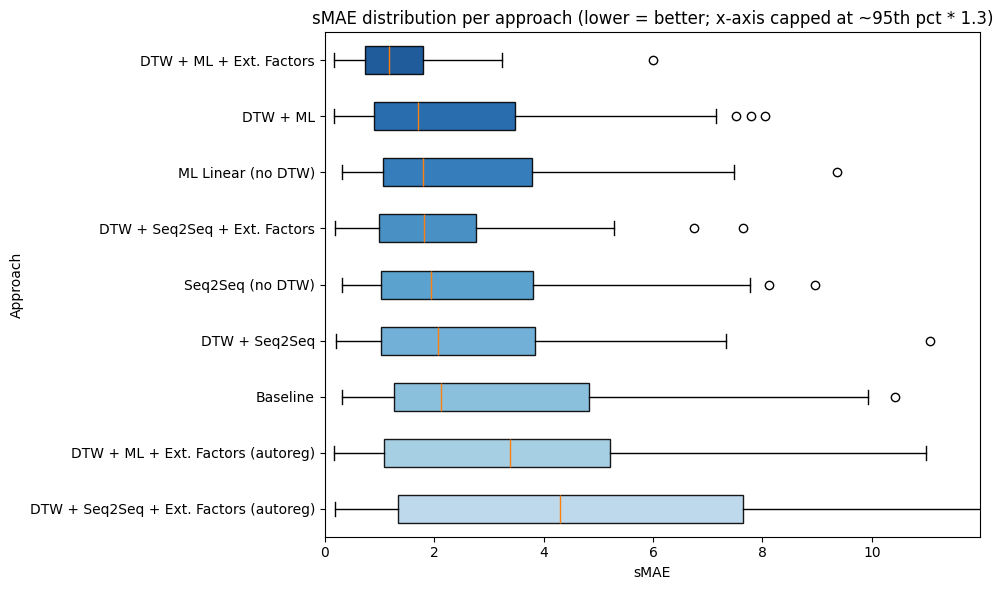

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare the data
df_box = df_energy_results[~df_energy_results['Approach'].isin(EXCLUDE_APPROACHES)].copy()
df_box['Approach'] = df_box['Approach'].replace(APPROACH_LABELS)
df_box = df_box.rename(columns={'sMAE_TEST': 'sMAE'})

# Sort approaches by median DESCENDING (ascending=False).
# Matplotlib horizontal boxplots build from bottom to top, 
# so making the lowest median last puts it at the very top of the chart.
box_order = df_box.groupby('Approach')['sMAE'].median().sort_values(ascending=False).index.tolist()

metric = 'sMAE'
fig, ax = plt.subplots(figsize=(10, 6))

data = [df_box.loc[df_box['Approach'] == a, metric].dropna().values for a in box_order]

# vert=False makes it horizontal (labels on left, values on x-axis)
# patch_artist=True allows us to fill the boxes with color
bplot = ax.boxplot(data, tick_labels=box_order, showfliers=True, vert=False, patch_artist=True)

# Add different scales of blue using the 'Blues' colormap
# We start at 0.3 so the lightest blue isn't completely white/invisible
colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(data)))
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_edgecolor('black') # Added black edges so the boxes stand out better
    patch.set_alpha(0.9)

# Cap the x-axis a bit above the 95th percentile
all_vals = np.concatenate([d for d in data if len(d)])
x_cap = np.percentile(all_vals, 95) * 1.3
ax.set_xlim(0, x_cap)

# Update titles and labels
ax.set_title(f'{metric} distribution per approach (lower = better; x-axis capped at ~95th pct * 1.3)')
ax.set_xlabel(metric)
ax.set_ylabel('Approach')

fig.tight_layout()
fig.savefig(run_dir / 'plots' / 'energy_approach_sMAE_boxplot.png', dpi=130)
plt.show()

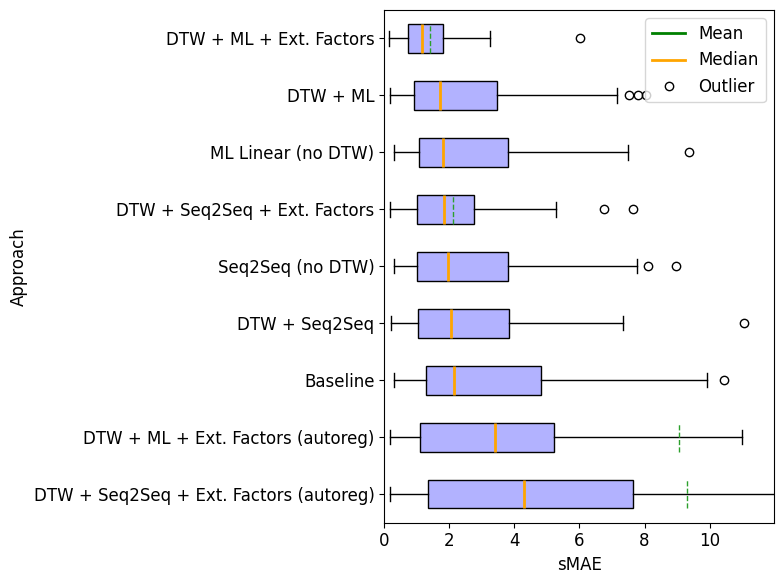

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

# Set global font size to 12 so all text is bigger
plt.rcParams.update({'font.size': 12})

# Prepare the data
df_box = df_energy_results[~df_energy_results['Approach'].isin(EXCLUDE_APPROACHES)].copy()
df_box['Approach'] = df_box['Approach'].replace(APPROACH_LABELS)
df_box = df_box.rename(columns={'sMAE_TEST': 'sMAE'})

# Sort approaches by median DESCENDING (ascending=False).
box_order = df_box.groupby('Approach')['sMAE'].median().sort_values(ascending=False).index.tolist()

metric = 'sMAE'
# Reduced width from 10 to 8 to make it less wide
fig, ax = plt.subplots(figsize=(8, 6))

data = [df_box.loc[df_box['Approach'] == a, metric].dropna().values for a in box_order]

# meanline=True turns the mean marker into a line across the box
# meanprops allows us to customize the color/style of that mean line
bplot = ax.boxplot(
    data, 
    tick_labels=box_order, 
    showfliers=True, 
    showmeans=True, 
    meanline=True, 
    vert=False, 
    patch_artist=True,
    meanprops=dict(color='green', linewidth=2, linestyle='-'),
    medianprops=dict(color='orange', linewidth=2)
)

# Apply the requested blue with alpha=0.1
# We apply alpha only to the facecolor so the black edges remain solid and visible
blue_rgba = mcolors.to_rgba('blue', alpha=0.3)

for patch in bplot['boxes']:
    patch.set_facecolor(blue_rgba)
    patch.set_edgecolor('black')

# Cap the x-axis a bit above the 95th percentile
all_vals = np.concatenate([d for d in data if len(d)])
x_cap = np.percentile(all_vals, 95) * 1.3
ax.set_xlim(0, x_cap)

# Update labels
ax.set_xlabel(metric)
ax.set_ylabel('Approach')

# Create custom legend for Mean, Median, and Outlier
legend_elements = [
    Line2D([0], [0], color='green', lw=2, linestyle='-', label='Mean'),
    Line2D([0], [0], color='orange', lw=2, label='Median'),
    Line2D([0], [0], marker='o', color='w', markeredgecolor='black', markerfacecolor='none', markersize=6, label='Outlier')
]
ax.legend(handles=legend_elements, loc='upper right')


fig.tight_layout()
fig.savefig('visuals/energy_approach_sMAE_boxplot.pdf', dpi=1300)
plt.show()

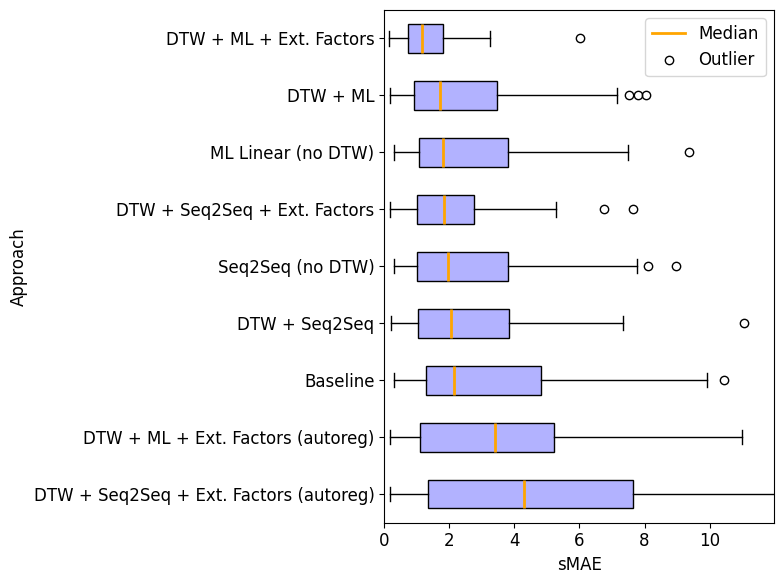

In [33]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

# Set global font size to 12 so all text is bigger
plt.rcParams.update({'font.size': 12})

# Prepare the data
df_box = df_energy_results[~df_energy_results['Approach'].isin(EXCLUDE_APPROACHES)].copy()
df_box['Approach'] = df_box['Approach'].replace(APPROACH_LABELS)
df_box = df_box.rename(columns={'sMAE_TEST': 'sMAE'})

# Sort approaches by median DESCENDING (ascending=False).
box_order = df_box.groupby('Approach')['sMAE'].median().sort_values(ascending=False).index.tolist()

metric = 'sMAE'

fig, ax = plt.subplots(figsize=(8, 6))

data = [df_box.loc[df_box['Approach'] == a, metric].dropna().values for a in box_order]

bplot = ax.boxplot(
    data, 
    tick_labels=box_order, 
    showfliers=True, 
    showmeans=False, 
    vert=False, 
    patch_artist=True,
    medianprops=dict(color='orange', linewidth=2)
)

# Apply the requested blue with alpha=0.3
# We apply alpha only to the facecolor so the black edges remain solid and visible
blue_rgba = mcolors.to_rgba('blue', alpha=0.3)

for patch in bplot['boxes']:
    patch.set_facecolor(blue_rgba)
    patch.set_edgecolor('black')

# Cap the x-axis a bit above the 95th percentile
all_vals = np.concatenate([d for d in data if len(d)])
x_cap = np.percentile(all_vals, 95) * 1.3
ax.set_xlim(0, x_cap)

# Update labels
ax.set_xlabel(metric)
ax.set_ylabel('Approach')

# Create custom legend for Median and Outlier
legend_elements = [
    Line2D([0], [0], color='orange', lw=2, label='Median'),
    Line2D([0], [0], marker='o', color='w',
           markeredgecolor='black', markerfacecolor='none',
           markersize=6, label='Outlier')
]
ax.legend(handles=legend_elements, loc='upper right')

fig.tight_layout()
fig.savefig('visuals/energy_approach_sMAE_boxplot.pdf', dpi=1300)
plt.show()

In [14]:
df_energy_results = pd.read_parquet(run_dir / 'summary_train_test.parquet')

#df_energy_results = df_energy_results[['Approach', 'MAE_TEST', 'RMSE_TEST', 'WAPE_TEST']]

df_energy_results

,Process,Sensor,Approach,MAE_TRAIN,RMSE_TRAIN,WAPE_TRAIN,sMAE_TRAIN,sRMSE_TRAIN,MAE_TEST,RMSE_TEST,WAPE_TEST,sMAE_TEST,sRMSE_TEST
0,process_1,autoclave_cooling_water_demand_kW_energy_to_model,Baseline,0.1366,0.1366,30.2989,0.8523,1.0279,0.1366,0.1366,32.2690,0.8862,1.1648
1,process_1,autoclave_cooling_water_demand_kW_energy_to_model,DTW + Ext. Factors + Prev Act,0.0126,0.0126,4.9600,0.1419,0.2004,0.0142,0.0185,5.7317,0.1629,0.2328
2,process_1,autoclave_cooling_water_demand_kW_energy_to_model,DTW + Ext. Factors + Prev Act (autoreg),0.0126,0.0126,5.1192,0.1464,0.2099,0.0133,0.0172,5.9562,0.1695,0.2465
3,process_1,autoclave_cooling_water_demand_kW_energy_to_model,DTW + Seq2Seq,0.0300,0.0340,5.9546,0.1707,0.2388,0.0297,0.0338,7.0707,0.2027,0.2926
4,process_1,autoclave_cooling_water_demand_kW_energy_to_model,DTW + Seq2Seq + Ext. Factors + Prev Act,0.0159,0.0168,5.2000,0.1494,0.2077,0.0183,0.0193,6.6539,0.1892,0.2664
...,...,...,...,...,...,...,...,...,...,...,...,...,...
732,process_5,vor_Vorwärmer_(WT_2)_5s_energy_to_model,DTW + pos,0.5142,0.5974,0.8762,0.7996,0.9414,1.1419,1.2741,1.9595,1.7319,1.9544
733,process_5,vor_Vorwärmer_(WT_2)_5s_energy_to_model,ML DTW + Linear Decode,0.6485,0.7201,1.1039,1.0262,1.2851,1.3057,1.4739,2.2653,1.8367,2.1054
734,process_5,vor_Vorwärmer_(WT_2)_5s_energy_to_model,ML Linear (no DTW),0.4630,0.5165,0.7851,0.7325,0.9117,1.3381,1.5404,2.3072,1.8324,2.1235
735,process_5,vor_Vorwärmer_(WT_2)_5s_energy_to_model,Seq2Seq DTW + Linear Decode,0.7653,0.8624,1.2932,1.0605,1.2901,1.3135,1.4118,2.2577,1.8648,2.0770


In [15]:
df_energy_results['Approach'].unique()

array(['Baseline', 'DTW + Ext. Factors + Prev Act',
       'DTW + Ext. Factors + Prev Act (autoreg)', 'DTW + Seq2Seq',
       'DTW + Seq2Seq + Ext. Factors + Prev Act',
       'DTW + Seq2Seq + Ext. Factors + Prev Act (autoreg)', 'DTW + pos',
       'ML DTW + Linear Decode', 'ML Linear (no DTW)',
       'Seq2Seq DTW + Linear Decode', 'Seq2Seq only (no DTW)'],
      dtype=object)

In [16]:
df_energy_results['Process'].value_counts()

Process
process_5    308
process_4    253
process_1     66
process_3     55
process_2     55
Name: count, dtype: int64

# Joint Duration + Profile Evaluation

Three tables:
1. **All together** — median sMAE / sRMSE / WAPE per curve approach, aggregated over all processes (best SimMode per process used for durations).
2. **Per simulation mode** — rows = simulation mode sorted by duration WAPE, cols = curve metrics; one table per process × curve approach (requires `curve_joint_duration_eval_per_mode.parquet` from a fresh pipeline run).
3. **Combined** — the process-results table from above extended with curve columns for Baseline and best curve approach; shows that curve quality degrades together with duration quality.

In [17]:
import re as _re

# ── Joint eval ALL TOGETHER — median by Approach across all processes ─────────
_jall_path = run_dir / 'curve_joint_duration_eval_results.parquet'
if not _jall_path.exists():
    print(f'Not found: {_jall_path}  (run the pipeline first)')
else:
    _jall = pd.read_parquet(_jall_path)
    _jm = [m for m in ['sMAE', 'sRMSE', 'WAPE'] if m in _jall.columns]

    # Median per Approach (across all processes, sensors, activities)
    _jall_agg = _jall.groupby('Approach')[_jm].median().round(4)
    _sort_col  = 'WAPE' if 'WAPE' in _jall_agg.columns else _jm[0]
    _jall_agg  = _jall_agg.sort_values(_sort_col)
    display(_jall_agg)

    # Bold the best (lowest) per column
    _jall_str = pd.DataFrame(index=_jall_agg.index, columns=_jall_agg.columns, dtype=object)
    for _c in _jall_agg.columns:
        _best = _jall_agg[_c].dropna().min()
        for _idx in _jall_agg.index:
            _v = _jall_agg.loc[_idx, _c]
            if pd.isna(_v):
                _jall_str.loc[_idx, _c] = ''
            else:
                _fmt = f'{_v:.3f}'
                _jall_str.loc[_idx, _c] = (r'\textbf{' + _fmt + r'}') if abs(_v - _best) < 1e-6 else _fmt

    _jall_str.columns = [
        r'\makecell{sMAE}' if c == 'sMAE' else
        r'\makecell{sRMSE}' if c == 'sRMSE' else
        r'\makecell{WAPE (\%)}' for c in _jall_str.columns
    ]
    _jall_latex = _jall_str.to_latex(
        escape=False,
        column_format='l|' + '|'.join(['c'] * len(_jm)),
        caption=(
            r'Joint duration + profile evaluation: median sMAE / sRMSE / WAPE per curve approach, '
            r'aggregated over all processes and sensors. '
            r'Simulated durations come from the best process model per process (lowest test duration WAPE). '
            r'Lower is better. \textbf{Bold} = best approach.'
        ),
        label=f'tab:joint_eval_all_{EXPERIMENT}',
        position='H',
    )
    print(_jall_latex.replace('_', r'\_'))

Not found: ../results/experiment_801_20260708_083236/curve_joint_duration_eval_results.parquet  (run the pipeline first)


In [18]:
# ── Joint eval PER SIMULATION MODE ───────────────────────────────────────────
# Rows = simulation mode sorted by duration WAPE (best first).
# Columns = sMAE / sRMSE / WAPE for Baseline and best curve approach per process.
# Requires curve_joint_duration_eval_per_mode.parquet (generated by the new pipeline block).

_jpm_path = run_dir / 'curve_joint_duration_eval_per_mode.parquet'
if not _jpm_path.exists():
    print(f'Per-mode joint eval not found at:\n  {_jpm_path}\n'
          'Re-run the pipeline after the modelling.py update to generate this file.')
else:
    _jpm = pd.read_parquet(_jpm_path)
    _jpm_metrics = [m for m in ['sMAE', 'sRMSE', 'WAPE'] if m in _jpm.columns]

    # Duration WAPE per (process, mode) for row ordering
    _pe2 = pd.read_parquet(run_dir / 'process_eval_results.parquet')
    _wc2 = next((c for c in ['test_duration_metrics_activity_duration_wape',
                              'test_duration_metrics_activity_duration_mae']
                 if c in _pe2.columns), None)
    _mwape = {}
    if _wc2:
        for (_pp, _pm), _gg in _pe2.groupby(['process', 'mode']):
            _vv = _gg[_wc2].dropna()
            if not _vv.empty:
                _mwape[(_pp, _pm)] = float(_vv.min())

    # Best curve approach per process (lowest median WAPE_TEST)
    _stp = run_dir / 'summary_train_test.parquet'
    _best_appr_pm = {}
    if _stp.exists():
        _stdf = pd.read_parquet(_stp)
        for _pr, _sg in _stdf.groupby('Process'):
            _pa = _sg.groupby('Approach')['WAPE_TEST'].median()
            if not _pa.empty:
                _best_appr_pm[_pr] = _pa.idxmin()

    def _fmt_sim_mode(m):
        m = str(m)
        if not m.startswith('petri_net_'):
            return m.replace('_', r'\_')
        rest = m[len('petri_net_'):]
        if rest.endswith('_ml_plus_per_act'):
            return rest[:-len('_ml_plus_per_act')].replace('_', r'\_') + r' / ml\_local'
        if rest.endswith('_ml_plus_global'):
            return rest[:-len('_ml_plus_global')].replace('_', r'\_') + r' / ml\_global'
        return rest.replace('_', r'\_') + r' / baseline'

    _pm_latex_parts = []

    for _proc in processes:
        _psub = _jpm[_jpm['Process'] == _proc]
        if _psub.empty:
            continue
        _best_ap = _best_appr_pm.get(_proc, 'Baseline')
        _mode_order = sorted(_psub['SimMode'].unique(),
                             key=lambda m: _mwape.get((_proc, m), 999))

        # One sub-table per approach (Baseline + best)
        for _ap_key, _ap_tag in [('Baseline', 'Baseline'), (_best_ap, 'Best')]:
            _sub_ap = (_psub[_psub['Approach'] == _ap_key]
                       .groupby('SimMode')[_jpm_metrics].median())
            if _sub_ap.empty:
                continue
            _sub_ap = _sub_ap.reindex(_mode_order).round(4)
            _sub_ap.index = [_fmt_sim_mode(m) for m in _sub_ap.index]

            # Bold best (lowest) per column
            _sub_str = pd.DataFrame(index=_sub_ap.index, columns=_sub_ap.columns, dtype=object)
            for _c in _sub_ap.columns:
                _best = _sub_ap[_c].dropna().min()
                for _idx in _sub_ap.index:
                    _v = _sub_ap.loc[_idx, _c]
                    if pd.isna(_v):
                        _sub_str.loc[_idx, _c] = ''
                    else:
                        _fmt2 = f'{_v:.3f}'
                        _sub_str.loc[_idx, _c] = (r'\textbf{' + _fmt2 + r'}') if abs(_v - _best) < 1e-6 else _fmt2

            _proc_ltx = _proc.replace("_", r"\_")
            _ap_key_ltx = _ap_key.replace("_", r"\_")  # if you want LaTeX-escaped underscores

            _sub_str.columns = [
                r'\makecell{sMAE}' if c == 'sMAE' else
                r'\makecell{sRMSE}' if c == 'sRMSE' else
                r'\makecell{WAPE (\%)}' for c in _sub_str.columns
            ]

            _col_fmt = 'l|' + '|'.join(['c'] * len(_jpm_metrics))

            _ltx = _sub_str.to_latex(
                escape=False,
                column_format=_col_fmt,
                caption=(
                    f'Joint eval per simulation mode — {_proc_ltx}, '
                    f'curve approach: {_ap_tag} ({_ap_key_ltx}). '
                    r'Rows sorted by test duration WAPE (best mode first). '
                    r'Lower is better. \textbf{Bold} = best simulation mode.'
                ),
                label=f'tab:joint_pm_{EXPERIMENT}_{_proc}_{_ap_tag.lower()}',
                position='H',
            )

            print(_ltx)
            _pm_latex_parts.append(_ltx)

Per-mode joint eval not found at:
  ../results/experiment_801_20260708_083236/curve_joint_duration_eval_per_mode.parquet
Re-run the pipeline after the modelling.py update to generate this file.


In [19]:
# ── COMBINED TABLE: process metrics + energy curve columns ────────────────────
# Same row structure as the main process-results table above.
# Three extra column groups added for Baseline and best curve approach:
#   sMAE | sRMSE | WAPE (energy)
# Source: curve_joint_duration_eval_per_mode.parquet (per-mode) if available,
#         falling back to curve_joint_duration_eval_results.parquet (best mode only).

_jpm_path  = run_dir / 'curve_joint_duration_eval_per_mode.parquet'
_jall_path = run_dir / 'curve_joint_duration_eval_results.parquet'

if _jpm_path.exists():
    _jsrc_comb = pd.read_parquet(_jpm_path)
    print(f'Using per-mode joint eval ({len(_jsrc_comb)} rows)')
elif _jall_path.exists():
    _jsrc_comb = pd.read_parquet(_jall_path)
    if 'BestMode' in _jsrc_comb.columns and 'SimMode' not in _jsrc_comb.columns:
        _jsrc_comb = _jsrc_comb.rename(columns={'BestMode': 'SimMode'})
    print(f'Per-mode file absent — using best-mode joint eval ({len(_jsrc_comb)} rows). '
          'Rows for non-best modes will show NaN in curve columns.')
else:
    _jsrc_comb = None
    print('No joint eval data found; run the pipeline first.')

if _jsrc_comb is not None:
    _comb_metrics = [m for m in ['sMAE', 'sRMSE', 'WAPE'] if m in _jsrc_comb.columns]

    # Pre-aggregate lookup: (Process, SimMode, Approach) → median curve metrics
    _jlkp = (
        _jsrc_comb
        .groupby(['Process', 'SimMode', 'Approach'])[_comb_metrics]
        .median()
    )

    # Best curve approach per process
    _stp2 = run_dir / 'summary_train_test.parquet'
    _best_ap_comb = {}
    if _stp2.exists():
        _stdf2 = pd.read_parquet(_stp2)
        for _pr2, _sg2 in _stdf2.groupby('Process'):
            _pa2 = _sg2.groupby('Approach')['WAPE_TEST'].median()
            if not _pa2.empty:
                _best_ap_comb[_pr2] = _pa2.idxmin()

    # Map (Process, ProcessModelLabel, DurationPredLabel) → raw SimMode string
    _pe_comb = pd.read_parquet(run_dir / 'process_eval_results.parquet')
    _ba_comb = {}
    for _pc in processes:
        _ba_comb[_pc] = pick_best_algo(_pe_comb[_pe_comb['process'] == _pc], split_prefix)

    def _label_to_simmode(proc, pmodel_lbl, dpred_lbl):
        ba = _ba_comb.get(proc, 'heuristic')
        if 'alpha' in pmodel_lbl:
            return 'petri_net_alpha'
        if 'ml_local'  in dpred_lbl: return f'petri_net_{ba}_ml_plus_per_act'
        if 'ml_global' in dpred_lbl: return f'petri_net_{ba}_ml_plus_global'
        return f'petri_net_{ba}'

    def _curve_vals(proc, sim_mode, approach):
        try:
            row = _jlkp.loc[(proc, sim_mode, approach)]
            return {m: row[m] for m in _comb_metrics}
        except KeyError:
            return {m: float('nan') for m in _comb_metrics}

    # ── Build extended table ──────────────────────────────────────────────────
    _ext_frames = []
    for proc in processes:
        sub_pe = _pe_comb[_pe_comb['process'] == proc]
        ba = _ba_comb[proc]
        best_ap = _best_ap_comb.get(proc, 'Baseline')
        pn = f'{ba} petri net'

        modes_to_show = ['petri_net_alpha', f'petri_net_{ba}',
                         f'petri_net_{ba}_ml_plus_global', f'petri_net_{ba}_ml_plus_per_act']
        sub_pe = sub_pe[sub_pe['mode'].isin(modes_to_show)].copy()
        sub_pe['mode_label'] = sub_pe['mode'].apply(lambda m: make_mode_label(m, ba))

        row_order = [f'{pn} / ml_local', f'{pn} / ml_global',
                     f'{pn} / baseline', 'alpha petri net / baseline']
        sub_pe = sub_pe.set_index('mode_label')[metric_cols]
        sub_pe = sub_pe.reindex([r for r in row_order if r in sub_pe.index])
        sub_pe.columns = [METRIC_LABELS.get(c, c) for c in sub_pe.columns]

        # Append curve metric columns for Baseline and best approach
        for _ck, _ctag in [('Baseline', 'Baseline'), (best_ap, 'Best')]:
            for _m in _comb_metrics:
                sub_pe[f'{_m} ({_ctag})'] = float('nan')

        for row_lbl in sub_pe.index:
            _pml, _dpl = split_mode(row_lbl)
            _sm = _label_to_simmode(proc, _pml, _dpl)
            for _ck, _ctag in [('Baseline', 'Baseline'), (best_ap, 'Best')]:
                _cv = _curve_vals(proc, _sm, _ck)
                for _m, _v in _cv.items():
                    sub_pe.loc[row_lbl, f'{_m} ({_ctag})'] = _v

        _pml_arr, _dpl_arr = zip(*[split_mode(r) for r in sub_pe.index])
        sub_pe.index = pd.MultiIndex.from_arrays(
            [[proc] * len(sub_pe), list(_pml_arr), list(_dpl_arr)],
            names=['Process', 'Process Model', 'Duration Pred.']
        )
        _ext_frames.append(sub_pe)

    ext_table = pd.concat(_ext_frames)
    display(ext_table)

    # ── LaTeX ─────────────────────────────────────────────────────────────────
    _higher_better_keys = {'F1 Score', 'Fitness', 'Precision'}

    def _is_hb_ext(col_label):
        return any(kw in col_label for kw in _higher_better_keys)

    _ext_str = pd.DataFrame(index=ext_table.index, columns=ext_table.columns, dtype=object)
    for proc in processes:
        _pmask = ext_table.index.get_level_values('Process') == proc
        _prows = ext_table[_pmask]
        for col in ext_table.columns:
            _vals = _prows[col].dropna()
            if _vals.empty:
                for idx in _prows.index: _ext_str.loc[idx, col] = ''
                continue
            _best_v = _vals.max() if _is_hb_ext(col) else _vals.min()
            for idx in _prows.index:
                _v2 = ext_table.loc[idx, col]
                if pd.isna(_v2):
                    _ext_str.loc[idx, col] = ''
                else:
                    _f2 = f'{_v2:.3f}'
                    _ext_str.loc[idx, col] = (r'\textbf{' + _f2 + r'}') if abs(_v2 - _best_v) < 1e-6 else _f2

    # Column format: process cols | baseline energy | best energy
    _n_proc   = len(metric_cols)
    _n_curve  = len(_comb_metrics)
    _col_fmt  = 'lll|' + '|'.join(['c'] * _n_proc) + '||' + '|'.join(['c'] * _n_curve) + '||' + '|'.join(['c'] * _n_curve)

    # Column header labels
    def _curve_col_label(m, tag):
        _nm = {'sMAE': r'sMAE', 'sRMSE': r'sRMSE', 'WAPE': r'WAPE\,(\%)'}
        return r'\makecell{' + _nm.get(m, m) + r'\\' + tag + r'}'

    _ext_str.columns = (
        [METRIC_LABELS.get(c, c) for c in metric_cols]
        + [_curve_col_label(m, 'Baseline') for m in _comb_metrics]
        + [_curve_col_label(m, 'Best')     for m in _comb_metrics]
    )

    _best_ap_label = ', '.join(sorted(set(_best_ap_comb.values())))
    _ext_latex = _ext_str.to_latex(
        multicolumn=True,
        multicolumn_format='c',
        multirow=True,
        escape=False,
        column_format=_col_fmt,
        caption=(
            f'Combined process and energy-curve results for experiment {EXPERIMENT} ({SPLIT} evaluation). '
            r'Left block: process model quality metrics (duration error, control-flow, conformance). '
            r'Middle block: energy curve quality using Baseline approach (mean barycenter, no DTW). '
            r'Right block: energy curve quality using the best curve approach per process '
            f'({_best_ap_label.replace("_", r"_")}). '
            r'Curve metrics are evaluated with simulated durations from each row\'s simulation mode '
            r'(shows how curve quality co-degrades with duration quality). '
            r'sMAE / sRMSE standardised by per-sensor std; WAPE is scale-free. '
            r'Lower is better for all metrics except Edge F1 Score, Fitness, Precision (higher = better). '
            r'\textbf{Bold} = best value per process per metric.'
        ),
        label=f'tab:combined_{EXPERIMENT}_{SPLIT}',
        position='H',
    )
    # Clean clines; insert midrules between processes
    _ext_latex = _re.sub(r'\s*\\cline\{[^}]+\}', '', _ext_latex)
    _ext_lines, _ext_new, _ext_cnt = _ext_latex.split('\n'), [], 0
    for _ln in _ext_lines:
        if _re.search(r'\\multirow.*\{process_', _ln):
            if _ext_cnt > 0: _ext_new.append(r'\midrule')
            _ext_cnt += 1
        _ext_new.append(_ln)
    _ext_latex = '\n'.join(_ext_new)
    print(_ext_latex.replace('_', r'\_'))

No joint eval data found; run the pipeline first.


# Energy Distribution Evaluation (case/activity/sensor and case/sensor)

No curve/instance matching -- compares the *distribution* of per-instance energy summary stats (mean/total per activity instance) between the real test set and the simulated log, via Wasserstein (Earth Mover) distance. Lower = simulated distribution closer to real. Reads `energy_distribution_results/<process>/<mode>/*.csv` from the run folder (populated only when `run_energy_modelling=True` for that run).

In [20]:
# -- Load energy-distribution results (case/sensor granularity, total_value) --
energy_dist_dir = run_dir / 'energy_distribution_results'
if not energy_dist_dir.exists():
    print(f'Not found: {energy_dist_dir}\n(run the pipeline with run_energy_modelling=True to generate it)')
    df_energy_dist = pd.DataFrame()
else:
    rows = []
    for proc_dir in sorted(energy_dist_dir.iterdir()):
        if not proc_dir.is_dir():
            continue
        for mode_dir in sorted(proc_dir.iterdir()):
            if not mode_dir.is_dir():
                continue
            csv_path = mode_dir / 'per_case_sensor_total.csv'
            core_path = mode_dir / 'core_metrics.csv'
            if not csv_path.exists():
                continue
            sensor_df = pd.read_csv(csv_path)
            # Recover the real mode string (not the filesystem-safe folder name) from core_metrics.csv
            mode_name = mode_dir.name
            if core_path.exists():
                core_df = pd.read_csv(core_path)
                if 'mode' in core_df.columns and len(core_df) > 0:
                    mode_name = core_df['mode'].iloc[0]
            for _, r in sensor_df.iterrows():
                rows.append({
                    'process': proc_dir.name,
                    'mode': mode_name,
                    'sensor': r['sensor'],
                    'wasserstein': r['wasserstein'],
                    'real_median': r.get('real_median'),
                    'sim_median': r.get('sim_median'),
                })
    df_energy_dist = pd.DataFrame(rows)

print(f'{len(df_energy_dist)} (process, mode, sensor) rows loaded')
df_energy_dist.head(20)

536 (process, mode, sensor) rows loaded


,process,mode,sensor,wasserstein,real_median,sim_median
0,process_1,petri_net_heuristic,autoclave_cooling_water_demand_kW_energy_to_model,1770.014631,1609.802544,6.516240e+01
1,process_1,petri_net_heuristic,autoclave_steam_demand_kW_energy_to_model,5541.518957,5653.071475,8.744730e+02
2,process_1,petri_net_heuristic,bottling_power_kW_energy_to_model,19.397390,16.467915,5.403729e-10
3,process_1,petri_net_heuristic,destillation_steam_demand_kW_energy_to_model,0.697211,0.006565,0.000000e+00
4,process_1,petri_net_heuristic,individual_packaging_power_kW_energy_to_model,106.541256,141.136955,5.461640e+01
5,process_1,petri_net_heuristic,water_supply_power_kW_energy_to_model,11.436351,4.576915,1.730211e+01
6,process_1,petri_net_heuristic_ml_plus_global,autoclave_cooling_water_demand_kW_energy_to_model,1770.014631,1609.802544,6.516240e+01
7,process_1,petri_net_heuristic_ml_plus_global,autoclave_steam_demand_kW_energy_to_model,5541.518957,5653.071475,8.744730e+02
8,process_1,petri_net_heuristic_ml_plus_global,bottling_power_kW_energy_to_model,19.397390,16.467915,5.403729e-10
9,process_1,petri_net_heuristic_ml_plus_global,destillation_steam_demand_kW_energy_to_model,0.697211,0.006565,0.000000e+00


In [21]:
# -- One table per process: rows = sensor, columns = mode (Wasserstein distance) --
# Sensor-as-rows keeps each table narrow (num. modes) regardless of how many
# sensors a process has, instead of one giant sparse table across all processes.
def shorten_sensor(name, max_len=40):
    name = str(name).replace('_energy_to_model', '').replace('_to_model', '')
    return name if len(name) <= max_len else name[:max_len - 1] + '…'

if df_energy_dist.empty:
    print('Nothing to show -- df_energy_dist is empty.')
else:
    df_energy_dist['mode_label'] = df_energy_dist['mode'].map(display_mode)

    for proc in sorted(df_energy_dist['process'].unique()):
        sub = df_energy_dist[df_energy_dist['process'] == proc].copy()
        sub['sensor_short'] = sub['sensor'].map(shorten_sensor)
        pivot = sub.pivot_table(index='sensor_short', columns='mode_label', values='wasserstein', aggfunc='first')

        # Bold the best (lowest) Wasserstein distance per sensor (row)
        str_table = pd.DataFrame(index=pivot.index, columns=pivot.columns, dtype=object)
        for idx in pivot.index:
            vals = pivot.loc[idx].dropna()
            if vals.empty:
                str_table.loc[idx] = ''
                continue
            best_val = vals.min()
            for col in pivot.columns:
                val = pivot.loc[idx, col]
                if pd.isna(val):
                    str_table.loc[idx, col] = ''
                    continue
                fmt = f'{val:.2f}'
                str_table.loc[idx, col] = (r'\textbf{' + fmt + r'}') if abs(val - best_val) < 1e-6 else fmt

        n_modes = len(pivot.columns)
        col_format = 'l|' + '|'.join(['c'] * n_modes)
        latex = str_table.to_latex(
            escape=False,
            column_format=col_format,
            caption=(
                f'Energy-distribution evaluation for {proc}, experiment {EXPERIMENT} ({SPLIT} evaluation). '
                r'Wasserstein (Earth Mover) distance between the per-case total energy distribution '
                r'(real vs.\ simulated), per sensor --- no curve/instance matching. '
                r'Lower is better. \textbf{Bold} = best mode per sensor.'
            ),
            label=f'tab:energy_dist_{EXPERIMENT}_{SPLIT}_{proc}',
            position='H',
        )
        print(f'% === {proc}: {pivot.shape[0]} sensors x {pivot.shape[1]} modes ===')
        print(latex.replace('_', r'\_'))
        print()

    display(df_energy_dist.pivot_table(index=['process', 'sensor'], columns='mode_label', values='wasserstein', aggfunc='first').round(2))

% === process_1: 6 sensors x 8 modes ===
\begin{table}[H]
\caption{Energy-distribution evaluation for process\_1, experiment 801 (test evaluation). Wasserstein (Earth Mover) distance between the per-case total energy distribution (real vs.\ simulated), per sensor --- no curve/instance matching. Lower is better. \textbf{Bold} = best mode per sensor.}
\label{tab:energy\_dist\_801\_test\_process\_1}
\begin{tabular}{l|c|c|c|c|c|c|c|c}
\toprule
mode\_label & heuristic / baseline & heuristic / ml\_global & heuristic / ml\_local & statistical & wip\_aware / baseline & wip\_aware / ml\_global & wip\_aware / ml\_local & wip\_branching\_aware / baseline \\
sensor\_short &  &  &  &  &  &  &  &  \\
\midrule
autoclave\_cooling\_water\_demand\_kW & 1770.01 & 1770.01 & 1770.01 & 1768.82 & 1770.01 & 1770.01 & 1770.01 & \textbf{1734.43} \\
autoclave\_steam\_demand\_kW & 5541.52 & 5541.52 & 5541.52 & 5545.72 & 5541.52 & 5541.52 & 5541.52 & \textbf{5267.23} \\
bottling\_power\_kW & \textbf{19.40} & \text

mode_label                                                    heuristic / baseline  \
process   sensor                                                                     
process_1 autoclave_cooling_water_demand_kW_energy_to_model                1770.01   
          autoclave_steam_demand_kW_energy_to_model                        5541.52   
          bottling_power_kW_energy_to_model                                  19.40   
          destillation_steam_demand_kW_energy_to_model                        0.70   
          individual_packaging_power_kW_energy_to_model                     106.54   
...                                                                            ...   
process_5 temp_nach_Kuehlturmkuehler_(WT6)_5s_energy_to_m...               8509.01   
          temp_nach_WR2,_vor_Druckerhoehungspumpe_(WT4)_5...              39622.06   
          temp_nach_WR2_(WT2)_5s_energy_to_model                           8820.24   
          temp_vor_Vorwärmer_(WT_2)_1h_energy_to_model                    26092.97   
          vor_Vorwärmer_(WT_2)_5s_energy_to_model                         26166.72   

mode_label                                                    heuristic / ml_global  \
process   sensor                                                                      
process_1 autoclave_cooling_water_demand_kW_energy_to_model                 1770.01   
          autoclave_steam_demand_kW_energy_to_model                         5541.52   
          bottling_power_kW_energy_to_model                                   19.40   
          destillation_steam_demand_kW_energy_to_model                         0.70   
          individual_packaging_power_kW_energy_to_model                      106.54   
...                                                                             ...   
process_5 temp_nach_Kuehlturmkuehler_(WT6)_5s_energy_to_m...                8657.50   
          temp_nach_WR2,_vor_Druckerhoehungspumpe_(WT4)_5...               40267.47   
          temp_nach_WR2_(WT2)_5s_energy_to_model                            8971.65   
          temp_vor_Vorwärmer_(WT_2)_1h_energy_to_model                     26529.50   
          vor_Vorwärmer_(WT_2)_5s_energy_to_model                          26600.22   

mode_label                                                    heuristic / ml_local  \
process   sensor                                                                     
process_1 autoclave_cooling_water_demand_kW_energy_to_model                1770.01   
          autoclave_steam_demand_kW_energy_to_model                        5541.52   
          bottling_power_kW_energy_to_model                                  19.40   
          destillation_steam_demand_kW_energy_to_model                        0.70   
          individual_packaging_power_kW_energy_to_model                     106.54   
...                                                                            ...   
process_5 temp_nach_Kuehlturmkuehler_(WT6)_5s_energy_to_m...               8637.83   
          temp_nach_WR2,_vor_Druckerhoehungspumpe_(WT4)_5...              40184.63   
          temp_nach_WR2_(WT2)_5s_energy_to_model                           8950.31   
          temp_vor_Vorwärmer_(WT_2)_1h_energy_to_model                    26472.37   
          vor_Vorwärmer_(WT_2)_5s_energy_to_model                         26544.07   

mode_label                                                    statistical  \
process   sensor                                                            
process_1 autoclave_cooling_water_demand_kW_energy_to_model       1768.82   
          autoclave_steam_demand_kW_energy_to_model               5545.72   
          bottling_power_kW_energy_to_model                         19.52   
          destillation_steam_demand_kW_energy_to_model               0.70   
          individual_packaging_power_kW_energy_to_model            111.67   
...                                                                   ...   
process_5 temp

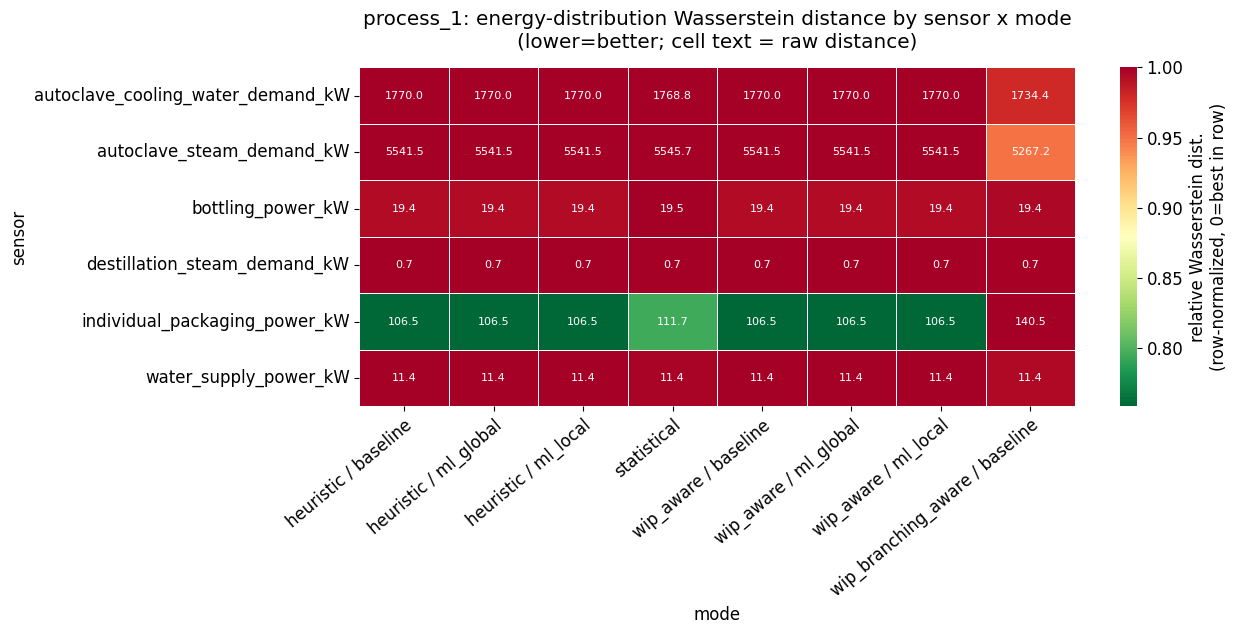

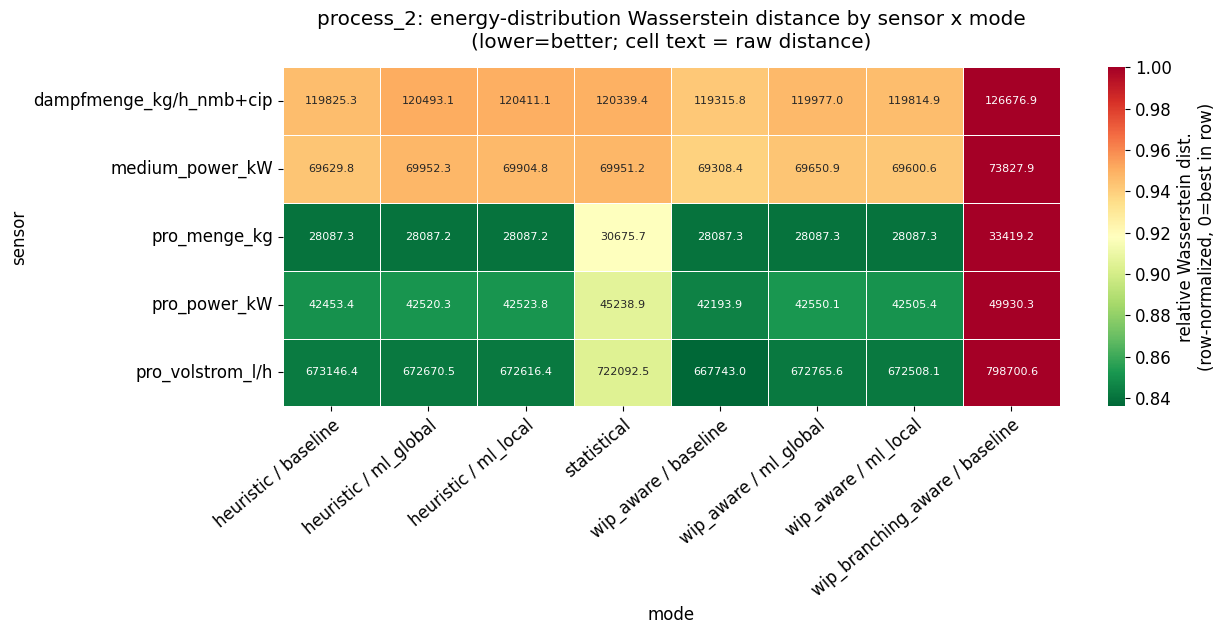

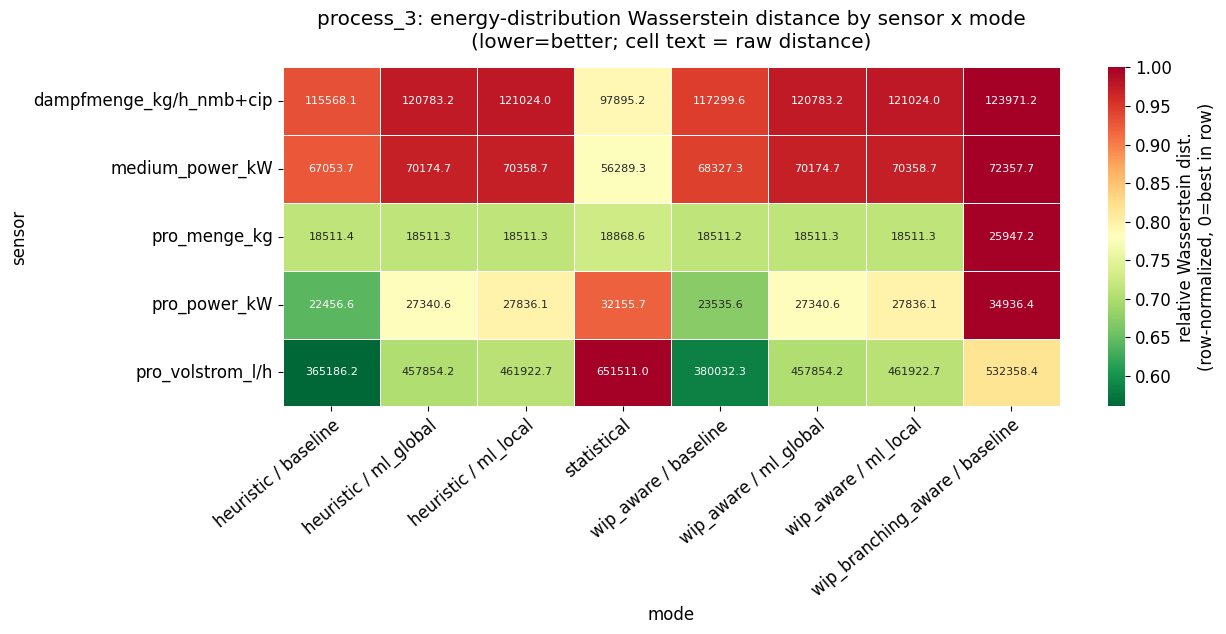

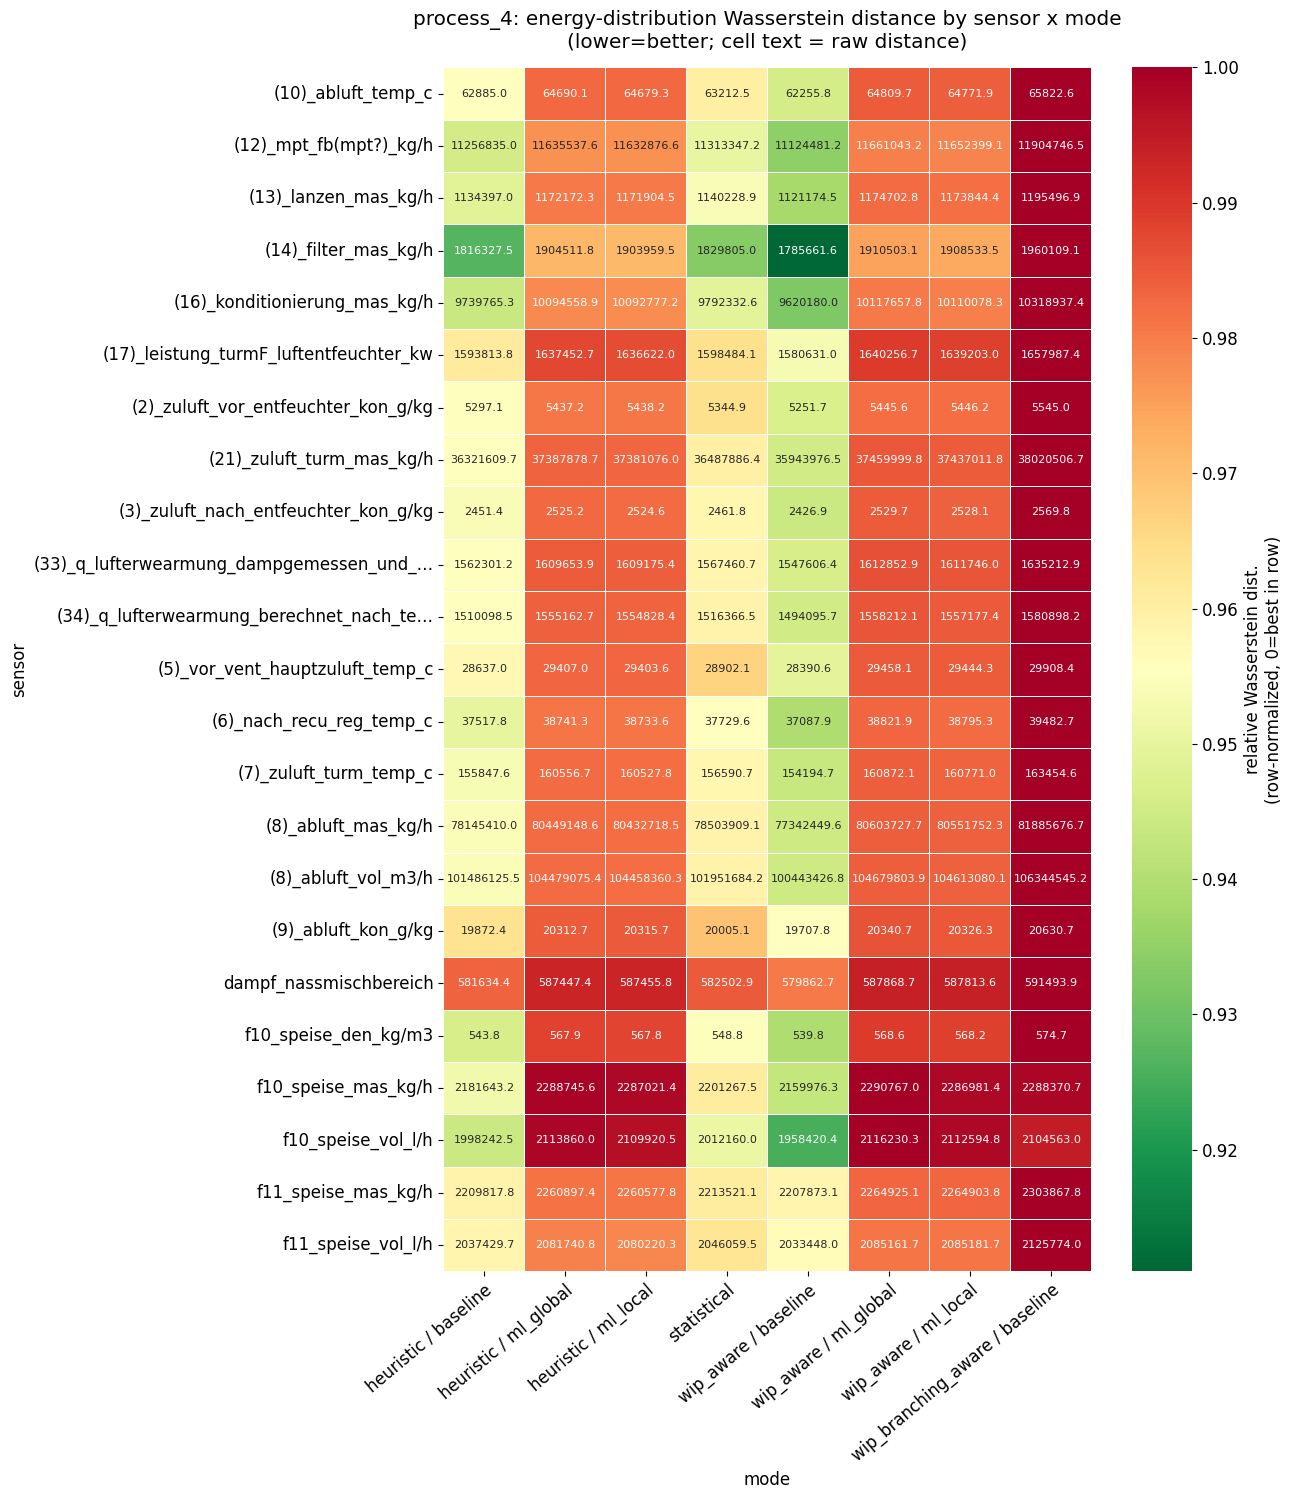

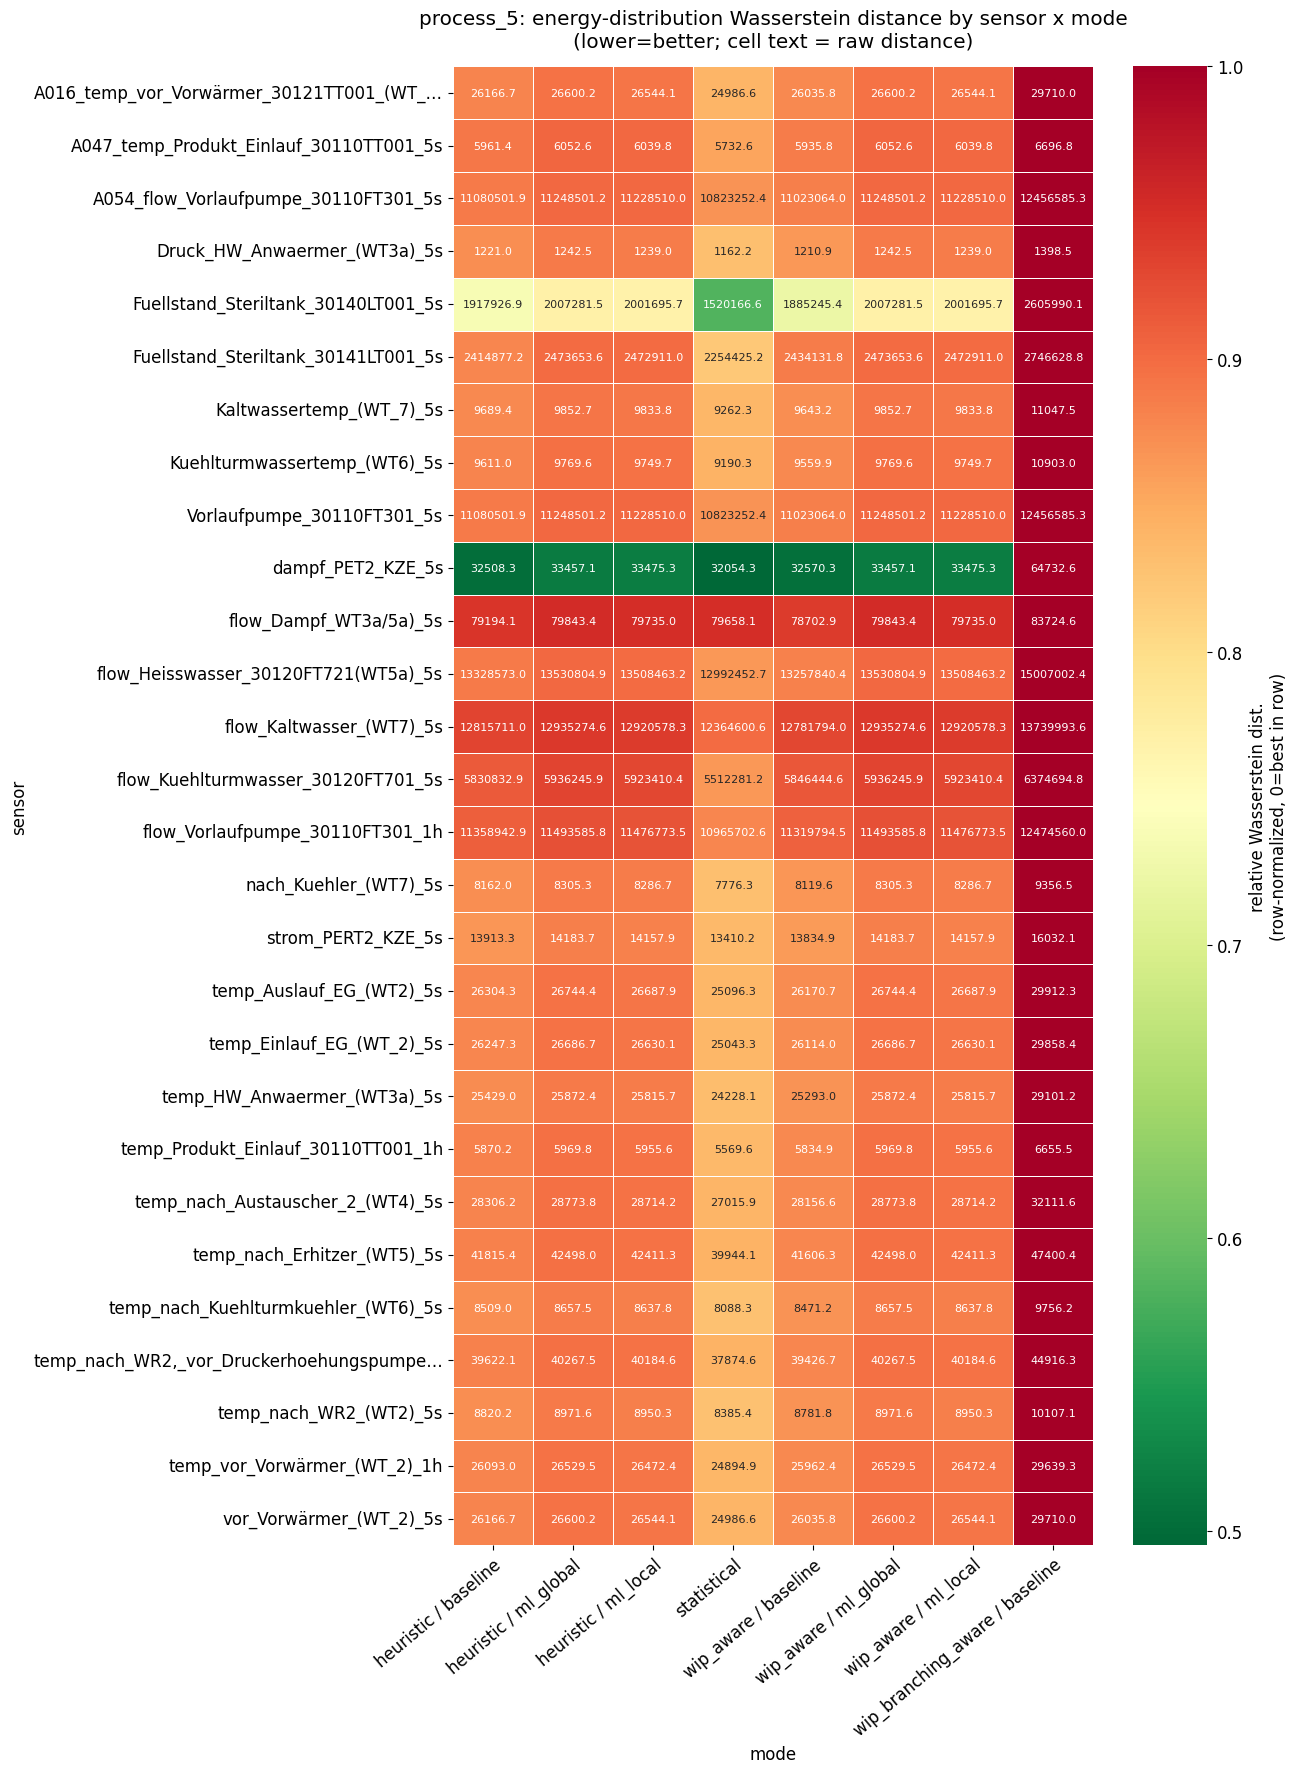

In [22]:
# -- Heatmap: sensor x mode, one per process (same data as the tables above) --
import matplotlib.pyplot as plt
import seaborn as sns

if df_energy_dist.empty:
    print('Nothing to show -- df_energy_dist is empty.')
else:
    heatmap_dir = run_dir / 'plots'
    heatmap_dir.mkdir(exist_ok=True)

    for proc in sorted(df_energy_dist['process'].unique()):
        sub = df_energy_dist[df_energy_dist['process'] == proc].copy()
        sub['sensor_short'] = sub['sensor'].map(shorten_sensor)
        pivot = sub.pivot_table(index='sensor_short', columns='mode_label', values='wasserstein', aggfunc='first')
        # Row-normalize for color (compares modes within a sensor); raw values shown as annotations.
        pivot_norm = pivot.div(pivot.max(axis=1), axis=0)

        n_rows, n_cols = pivot.shape
        fig_w = max(9, 1.6 * n_cols)
        fig_h = max(4, 0.55 * n_rows) + 2.5   # headroom for title + rotated xticklabels
        fig, ax = plt.subplots(figsize=(fig_w, fig_h))
        sns.heatmap(
            pivot_norm, annot=pivot.round(1), fmt='', cmap='RdYlGn_r',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'relative Wasserstein dist.\n(row-normalized, 0=best in row)'},
            annot_kws={'size': 8}, ax=ax,
        )
        ax.set_title(f'{proc}: energy-distribution Wasserstein distance by sensor x mode\n'
                     '(lower=better; cell text = raw distance)', pad=14)
        ax.set_xlabel('mode'); ax.set_ylabel('sensor')
        plt.setp(ax.get_xticklabels(), rotation=40, ha='right', rotation_mode='anchor')
        plt.setp(ax.get_yticklabels(), rotation=0)
        fig.tight_layout()
        fig.savefig(heatmap_dir / f'energy_dist_heatmap_{proc}.png', dpi=130)
        plt.show()

## Aggregated ranking (one number per process x method)

Rolls the per-sensor Wasserstein distances up to a single **scale-free** number per (process, mode): `relative_wasserstein = wasserstein / real_median`, so a kg/h sensor and a °C sensor can be averaged fairly. Median over sensors per process, then median over processes for `Overall`. Rows sorted best-to-worst.

In [23]:
# -- Aggregate: one relative-Wasserstein number per (process, mode) ----------
if df_energy_dist.empty:
    print('Nothing to show -- df_energy_dist is empty.')
else:
    df_energy_dist['relative_wasserstein'] = (
        df_energy_dist['wasserstein'] / df_energy_dist['real_median'].abs().replace(0, float('nan'))
    )
    rank_agg = df_energy_dist.groupby(['process', 'mode_label'])['relative_wasserstein'].median().reset_index()
    rank_pivot = rank_agg.pivot(index='mode_label', columns='process', values='relative_wasserstein')
    rank_pivot['Overall'] = rank_pivot.median(axis=1)
    rank_pivot = rank_pivot.sort_values('Overall')

    str_table = pd.DataFrame(index=rank_pivot.index, columns=rank_pivot.columns, dtype=object)
    for col in rank_pivot.columns:
        vals = rank_pivot[col].dropna()
        if vals.empty:
            str_table[col] = ''
            continue
        best_val = vals.min()
        for idx in rank_pivot.index:
            val = rank_pivot.loc[idx, col]
            if pd.isna(val):
                str_table.loc[idx, col] = ''
                continue
            fmt = f'{val:.3f}'
            str_table.loc[idx, col] = (r'\textbf{' + fmt + r'}') if abs(val - best_val) < 1e-6 else fmt

    n_cols = len(rank_pivot.columns)
    col_format = 'l|' + '|'.join(['c'] * (n_cols - 1)) + '|c'
    rank_latex = str_table.to_latex(
        escape=False, column_format=col_format,
        caption=(
            f'Aggregated energy-distribution ranking, experiment {EXPERIMENT} ({SPLIT} evaluation). '
            r'Median relative Wasserstein distance (Wasserstein / real median) over sensors per process, '
            r'then median over processes for Overall. '
            r'Lower is better. Rows sorted best-to-worst by Overall. \textbf{Bold} = best mode per column.'
        ),
        label=f'tab:energy_dist_ranking_{EXPERIMENT}_{SPLIT}',
        position='H',
    )
    print(rank_latex.replace('_', r'\_'))
    display(rank_pivot.round(3))

\begin{table}[H]
\caption{Aggregated energy-distribution ranking, experiment 801 (test evaluation). Median relative Wasserstein distance (Wasserstein / real median) over sensors per process, then median over processes for Overall. Lower is better. Rows sorted best-to-worst by Overall. \textbf{Bold} = best mode per column.}
\label{tab:energy\_dist\_ranking\_801\_test}
\begin{tabular}{l|c|c|c|c|c|c}
\toprule
process & process\_1 & process\_2 & process\_3 & process\_4 & process\_5 & Overall \\
mode\_label &  &  &  &  &  &  \\
\midrule
statistical & 1.142 & 1.013 & \textbf{1.304} & 0.908 & \textbf{1.086} & \textbf{1.086} \\
wip\_branching\_aware / baseline & \textbf{1.129} & 1.103 & 1.675 & 0.947 & 1.295 & 1.129 \\
wip\_aware / baseline & 1.139 & 0.927 & 1.583 & \textbf{0.895} & 1.133 & 1.133 \\
heuristic / baseline & 1.139 & 0.927 & 1.553 & 0.905 & 1.138 & 1.138 \\
heuristic / ml\_local & 1.139 & \textbf{0.927} & 1.630 & 0.931 & 1.155 & 1.139 \\
heuristic / ml\_global & 1.139 & \textbf{0.

process,process_1,process_2,process_3,process_4,process_5,Overall
mode_label,,,,,,
statistical,1.142,1.013,1.304,0.908,1.086,1.086
wip_branching_aware / baseline,1.129,1.103,1.675,0.947,1.295,1.129
wip_aware / baseline,1.139,0.927,1.583,0.895,1.133,1.133
heuristic / baseline,1.139,0.927,1.553,0.905,1.138,1.138
heuristic / ml_local,1.139,0.927,1.630,0.931,1.155,1.139
heuristic / ml_global,1.139,0.927,1.625,0.932,1.157,1.139
wip_aware / ml_global,1.139,0.927,1.625,0.933,1.157,1.139
wip_aware / ml_local,1.139,0.927,1.630,0.933,1.155,1.139


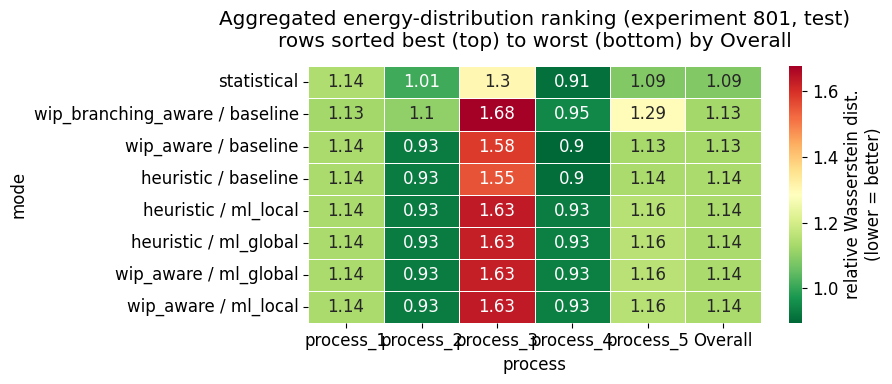

In [24]:
# -- Ranking heatmap: mode (rows, sorted best-to-worst) x process ------------
if df_energy_dist.empty:
    print('Nothing to show -- df_energy_dist is empty.')
else:
    fig, ax = plt.subplots(figsize=(max(8, 1.5 * len(rank_pivot.columns)), max(3, 0.5 * len(rank_pivot))))
    sns.heatmap(
        rank_pivot, annot=rank_pivot.round(2), fmt='', cmap='RdYlGn_r',
        linewidths=0.5, linecolor='white',
        cbar_kws={'label': 'relative Wasserstein dist.\n(lower = better)'},
        ax=ax,
    )
    ax.set_title(f'Aggregated energy-distribution ranking (experiment {EXPERIMENT}, {SPLIT})\n'
                 'rows sorted best (top) to worst (bottom) by Overall', pad=14)
    ax.set_xlabel('process'); ax.set_ylabel('mode')
    plt.setp(ax.get_yticklabels(), rotation=0)
    fig.tight_layout()
    fig.savefig(run_dir / 'plots' / 'energy_dist_ranking_heatmap.png', dpi=130)
    plt.show()

## Does process-model quality predict energy-profile quality?

Merges the existing process-fidelity metric (`test_overall_error`, from `process_eval_results.parquet`) with the energy-distribution ranking built above, one point per (process, mode).

**Important caveat, not swept under the rug**: several (process, mode) pairs produce a *numerically identical* simulated schedule as another mode in the same process -- e.g. `wip_aware_ml_plus_global` and `heuristic_ml_plus_global` are mathematically guaranteed to collapse to the same result whenever `MINING_ALGORITHM='heuristic'`, since ML+ duration prediction doesn't use wip/ro at all, and `wip_aware` reuses `MINING_ALGORITHM`'s own net. Including duplicate, non-independent observations inflates the sample size without adding real information, and pulls the correlation toward zero. The cell below detects these duplicates (by comparing each mode's predicted `sim_median` signature per process) and reports the correlation **with and without them** -- report the 'clean' number, not the naive one.

All 40 pairs (naive):        rho=-0.221  p=0.1706
Clean 24 pairs (duplicates removed): rho=+0.125  p=0.5599

16 of 40 pairs flagged as duplicate schedules.


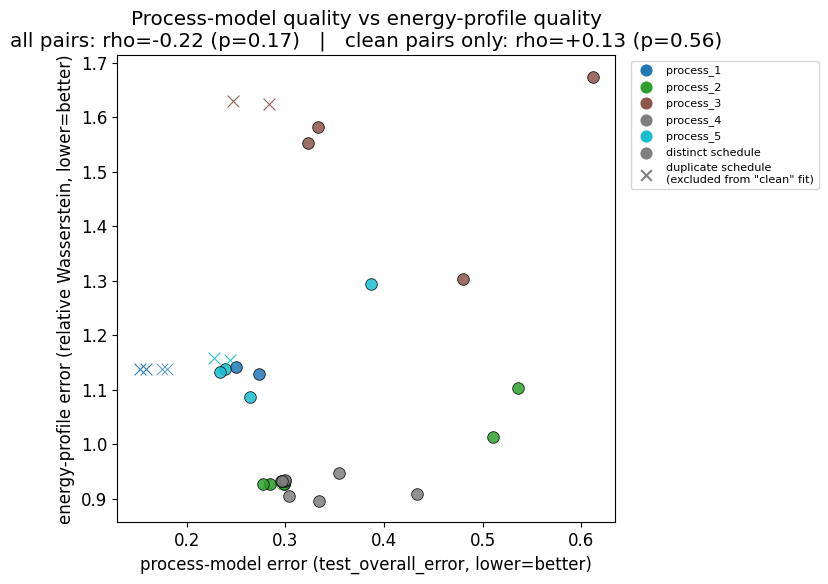

In [25]:
from scipy.stats import spearmanr

# -- process-model quality (already computed earlier as `df`) ---------------
proc_quality = df[['process', 'mode_label', 'test_overall_error']].dropna()

# -- detect duplicate-schedule (process, mode) pairs --------------------------
sig_rows = []
for proc_dir in sorted(energy_dist_dir.iterdir()):
    if not proc_dir.is_dir():
        continue
    for mode_dir in sorted(proc_dir.iterdir()):
        if not mode_dir.is_dir():
            continue
        csv_path = mode_dir / 'per_case_sensor_total.csv'
        core_path = mode_dir / 'core_metrics.csv'
        if not csv_path.exists():
            continue
        sensor_df = pd.read_csv(csv_path)
        mode_name = mode_dir.name
        if core_path.exists():
            core_df = pd.read_csv(core_path)
            if 'mode' in core_df.columns and len(core_df) > 0:
                mode_name = core_df['mode'].iloc[0]
        sig_rows.append({
            'process': proc_dir.name, 'mode': mode_name,
            'sig': tuple(sensor_df.sort_values('sensor')['sim_median'].round(3)),
        })
sig_df = pd.DataFrame(sig_rows)
sig_df['is_duplicate'] = sig_df.duplicated(subset=['process', 'sig'], keep=False)
sig_df['mode_label'] = sig_df['mode'].map(display_mode)

# -- energy-profile quality (reuse from the aggregated-ranking cell) ---------
corr_merged = proc_quality.merge(rank_agg, on=['process', 'mode_label'], how='inner')
corr_merged = corr_merged.merge(
    sig_df[['process', 'mode_label', 'is_duplicate']], on=['process', 'mode_label'], how='left'
)
clean = corr_merged[~corr_merged['is_duplicate']]

rho_all, p_all = spearmanr(corr_merged['test_overall_error'], corr_merged['relative_wasserstein'])
rho_clean, p_clean = spearmanr(clean['test_overall_error'], clean['relative_wasserstein'])
print(f'All {len(corr_merged)} pairs (naive):        rho={rho_all:+.3f}  p={p_all:.4f}')
print(f'Clean {len(clean)} pairs (duplicates removed): rho={rho_clean:+.3f}  p={p_clean:.4f}')
print(f'\n{corr_merged["is_duplicate"].sum()} of {len(corr_merged)} pairs flagged as duplicate schedules.')

# -- scatter plot --------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6))
processes_c = sorted(corr_merged['process'].unique())
colors_c = plt.cm.tab10(np.linspace(0, 1, len(processes_c)))
proc_color = dict(zip(processes_c, colors_c))
for _, r in corr_merged.iterrows():
    marker = 'x' if r['is_duplicate'] else 'o'
    ax.scatter(r['test_overall_error'], r['relative_wasserstein'],
               color=proc_color[r['process']], marker=marker, s=70,
               edgecolors=('black' if not r['is_duplicate'] else None), linewidths=0.6, alpha=0.85)
for proc in processes_c:
    ax.scatter([], [], color=proc_color[proc], label=proc, s=60)
ax.scatter([], [], color='gray', marker='o', label='distinct schedule', s=60)
ax.scatter([], [], color='gray', marker='x', label='duplicate schedule\n(excluded from "clean" fit)', s=60)
ax.set_xlabel('process-model error (test_overall_error, lower=better)')
ax.set_ylabel('energy-profile error (relative Wasserstein, lower=better)')
ax.set_title('Process-model quality vs energy-profile quality\n'
             f'all pairs: rho={rho_all:+.2f} (p={p_all:.2f})   |   '
             f'clean pairs only: rho={rho_clean:+.2f} (p={p_clean:.2f})')
ax.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1.02, 1))
fig.tight_layout()
fig.savefig(run_dir / 'plots' / 'energy_dist_correlation_scatter.png', dpi=130)
plt.show()

### The raw check, side by side

Full table behind the correlation above: one row per (process, mode), process-quality score, energy-quality score, and whether that row's simulated schedule is a duplicate of another mode's in the same process (both scores lower = better). Look at `process_1`: six rows share the exact same `energy_error` (0.9516...) despite different `process_error` values -- that's six "different modes" that produced the literal same simulated schedule, which is why they're excluded from the clean check.

In [26]:
# -- Full side-by-side table + both checks -----------------------------------
display_table = corr_merged.rename(
    columns={'test_overall_error': 'process_error', 'relative_wasserstein': 'energy_error'}
).sort_values(['process', 'energy_error'])[
    ['process', 'mode_label', 'process_error', 'energy_error', 'is_duplicate']
]
print('=== FULL TABLE: every (process, mode) pair used in the check ===')
display(display_table)

print(f'\n=== CHECK 1: naive, all {len(corr_merged)} pairs (duplicates included) ===')
print(f'rho={rho_all:+.3f}  p={p_all:.4f}   -> {"significant" if p_all < 0.05 else "NOT significant"}')

print(f'\n=== CHECK 2: clean, {len(clean)} pairs ({corr_merged["is_duplicate"].sum()} duplicates removed) ===')
print(f'rho={rho_clean:+.3f}  p={p_clean:.4f}   -> {"significant" if p_clean < 0.05 else "NOT significant"}')

print(f'\n=== The {corr_merged["is_duplicate"].sum()} duplicate rows removed for Check 2 ===')
display(
    corr_merged[corr_merged['is_duplicate']]
    .rename(columns={'test_overall_error': 'process_error', 'relative_wasserstein': 'energy_error'})
    .sort_values(['process', 'mode_label'])[['process', 'mode_label', 'process_error', 'energy_error']]
)

=== FULL TABLE: every (process, mode) pair used in the check ===


,process,mode_label,process_error,energy_error,is_duplicate
3,process_1,wip_branching_aware / baseline,0.273628,1.129093,False
1,process_1,heuristic / baseline,0.180435,1.138706,True
2,process_1,wip_aware / baseline,0.175134,1.138706,True
4,process_1,heuristic / ml_global,0.158892,1.138706,True
5,process_1,heuristic / ml_local,0.152385,1.138706,True
6,process_1,wip_aware / ml_global,0.159227,1.138706,True
7,process_1,wip_aware / ml_local,0.152385,1.138706,True
0,process_1,statistical,0.250323,1.142085,False
13,process_2,heuristic / ml_local,0.280713,0.927097,True
12,process_2,heuristic / ml_global,0.288378,0.927097,True



=== CHECK 1: naive, all 40 pairs (duplicates included) ===
rho=-0.221  p=0.1706   -> NOT significant

=== CHECK 2: clean, 24 pairs (16 duplicates removed) ===
rho=+0.125  p=0.5599   -> NOT significant

=== The 16 duplicate rows removed for Check 2 ===


,process,mode_label,process_error,energy_error
1,process_1,heuristic / baseline,0.180435,1.138706
4,process_1,heuristic / ml_global,0.158892,1.138706
5,process_1,heuristic / ml_local,0.152385,1.138706
2,process_1,wip_aware / baseline,0.175134,1.138706
6,process_1,wip_aware / ml_global,0.159227,1.138706
7,process_1,wip_aware / ml_local,0.152385,1.138706
12,process_2,heuristic / ml_global,0.288378,0.927097
13,process_2,heuristic / ml_local,0.280713,0.927097
20,process_3,heuristic / ml_global,0.283059,1.625459
21,process_3,heuristic / ml_local,0.246671,1.629722


## Same check, but per (process, mode, sensor) -- not aggregated per process

The scatter above collapsed every sensor within a (process, mode) down to one median point (40 dots, 26 after removing duplicates). This version keeps every sensor as its own point instead -- ~536 dots across all processes together, plotted on one shared scatter (log scale on the y-axis, since relative Wasserstein distance spans several orders of magnitude across sensors). Same duplicate-schedule exclusion as before, same process_error x-axis. More points, more noise visible, but also much higher statistical power -- the correlation holds (and is stronger) even without removing duplicates.

All (process, mode, sensor) points: n=536  rho=-0.319  p=3.65e-14
Clean (non-duplicate) points:       n=358  rho=-0.178  p=0.0007047


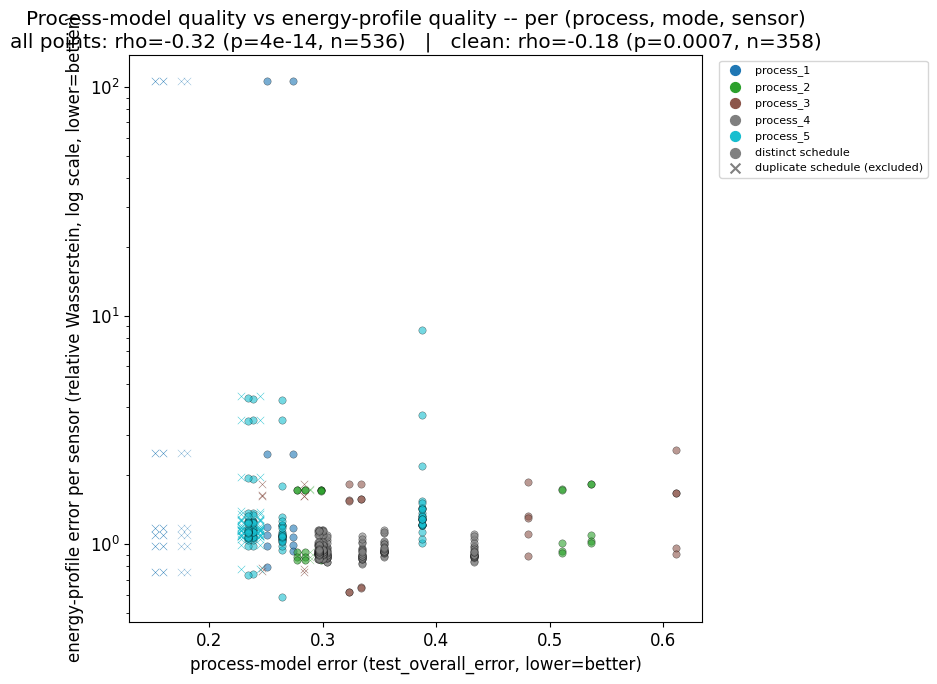

In [27]:
# -- Per (process, mode, sensor): no aggregation, all processes on one plot --
instance_merged = df_energy_dist.merge(proc_quality, on=['process', 'mode_label'], how='inner')
instance_merged = instance_merged.merge(
    sig_df[['process', 'mode_label', 'is_duplicate']], on=['process', 'mode_label'], how='left'
)
instance_merged = instance_merged.dropna(subset=['relative_wasserstein', 'test_overall_error'])
instance_clean = instance_merged[~instance_merged['is_duplicate']]

rho_i_all, p_i_all = spearmanr(instance_merged['test_overall_error'], instance_merged['relative_wasserstein'])
rho_i_clean, p_i_clean = spearmanr(instance_clean['test_overall_error'], instance_clean['relative_wasserstein'])
print(f'All (process, mode, sensor) points: n={len(instance_merged)}  rho={rho_i_all:+.3f}  p={p_i_all:.4g}')
print(f'Clean (non-duplicate) points:       n={len(instance_clean)}  rho={rho_i_clean:+.3f}  p={p_i_clean:.4g}')

fig, ax = plt.subplots(figsize=(9, 7))
processes_i = sorted(instance_merged['process'].unique())
colors_i = plt.cm.tab10(np.linspace(0, 1, len(processes_i)))
proc_color_i = dict(zip(processes_i, colors_i))
for _, r in instance_merged.iterrows():
    marker = 'x' if r['is_duplicate'] else 'o'
    ax.scatter(r['test_overall_error'], r['relative_wasserstein'],
               color=proc_color_i[r['process']], marker=marker, s=28,
               edgecolors=('black' if not r['is_duplicate'] else None), linewidths=0.3, alpha=0.6)
for proc in processes_i:
    ax.scatter([], [], color=proc_color_i[proc], label=proc, s=50)
ax.scatter([], [], color='gray', marker='o', label='distinct schedule', s=50)
ax.scatter([], [], color='gray', marker='x', label='duplicate schedule (excluded)', s=50)
ax.set_yscale('log')
ax.set_xlabel('process-model error (test_overall_error, lower=better)')
ax.set_ylabel('energy-profile error per sensor (relative Wasserstein, log scale, lower=better)')
ax.set_title('Process-model quality vs energy-profile quality -- per (process, mode, sensor)\n'
             f'all points: rho={rho_i_all:+.2f} (p={p_i_all:.1g}, n={len(instance_merged)})   |   '
             f'clean: rho={rho_i_clean:+.2f} (p={p_i_clean:.1g}, n={len(instance_clean)})')
ax.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1.02, 1))
fig.tight_layout()
fig.savefig(run_dir / 'plots' / 'energy_dist_correlation_scatter_per_sensor.png', dpi=130)
plt.show()